In [ ]:
print("=" * 70)
print("NOTEBOOK 4: FIFA WORLD CUP 2026 MODEL EVALUATION")
print("=" * 70)

NOTEBOOK 4: FIFA WORLD CUP 2026 MODEL EVALUATION


In [ ]:
!pip -q install xgboost

import os
import glob
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    log_loss,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
import pandas as pd
import numpy as np
matches_clean = pd.read_csv("/content/sample_data/matches_men_clean.csv")

classification_df = pd.read_csv(
    "/content/sample_data/mens_classification_dataset.csv"
)

elo_df = pd.read_csv(
    "/content/sample_data/mens_final_elo.csv"
)

modeling_df = pd.read_csv(
    "/content/sample_data/mens_modeling_dataset.csv"
)

poisson_df = pd.read_csv(
    "/content/sample_data/mens_poisson_dataset.csv"
)

cross_validation_results = pd.read_csv(
    "/content/sample_data/cross_validation_results.csv"
)

print("All datasets loaded successfully.")

print("\nMatches clean:", matches_clean.shape)
print("Classification dataset:", classification_df.shape)
print("ELO dataset:", elo_df.shape)
print("Modeling dataset:", modeling_df.shape)
print("Poisson dataset:", poisson_df.shape)
print("Cross-validation results:", cross_validation_results.shape)

All datasets loaded successfully.

Matches clean: (358, 17)
Classification dataset: (358, 29)
ELO dataset: (64, 3)
Modeling dataset: (358, 33)
Poisson dataset: (358, 29)
Cross-validation results: (4, 3)


In [ ]:
print("CLASSIFICATION DATA")
display(classification_df.head())
print(classification_df.columns.tolist())

print("\nMODELING DATA")
display(modeling_df.head())
print(modeling_df.columns.tolist())

print("\nPOISSON DATA")
display(poisson_df.head())
print(poisson_df.columns.tolist())

print("\nELO DATA")
display(elo_df.head())
print(elo_df.columns.tolist())

CLASSIFICATION DATA


,date,tournament,year,round,team_a,team_b,elo_a,elo_b,elo_diff,form_points_a,form_points_b,form_diff,avg_goals_for_a,avg_goals_for_b,goals_for_diff,avg_goals_against_a,avg_goals_against_b,goals_against_diff,avg_goal_diff_a,avg_goal_diff_b,recent_goal_diff,win_rate_a,win_rate_b,win_rate_diff,recent_games_a,recent_games_b,is_knockout,result,target
0,2010-06-11,World Cup,2010,Matchday 1,South Africa,Mexico,1500.0,1500.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.33,0.33,0.0,0,0,0,Draw,1
1,2010-06-11,World Cup,2010,Matchday 1,Uruguay,France,1500.0,1500.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.33,0.33,0.0,0,0,0,Draw,1
2,2010-06-12,World Cup,2010,Matchday 2,South Korea,Greece,1500.0,1500.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.33,0.33,0.0,0,0,0,Team A Win,2
3,2010-06-12,World Cup,2010,Matchday 2,Argentina,Nigeria,1500.0,1500.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.33,0.33,0.0,0,0,0,Team A Win,2
4,2010-06-12,World Cup,2010,Matchday 2,England,USA,1500.0,1500.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.33,0.33,0.0,0,0,0,Draw,1


['date', 'tournament', 'year', 'round', 'team_a', 'team_b', 'elo_a', 'elo_b', 'elo_diff', 'form_points_a', 'form_points_b', 'form_diff', 'avg_goals_for_a', 'avg_goals_for_b', 'goals_for_diff', 'avg_goals_against_a', 'avg_goals_against_b', 'goals_against_diff', 'avg_goal_diff_a', 'avg_goal_diff_b', 'recent_goal_diff', 'win_rate_a', 'win_rate_b', 'win_rate_diff', 'recent_games_a', 'recent_games_b', 'is_knockout', 'result', 'target']

MODELING DATA


,date,tournament,year,round,team_a,team_b,elo_a,elo_b,elo_diff,recent_games_a,recent_games_b,form_points_a,form_points_b,form_diff,avg_goals_for_a,avg_goals_for_b,goals_for_diff,avg_goals_against_a,avg_goals_against_b,goals_against_diff,avg_goal_diff_a,avg_goal_diff_b,recent_goal_diff,win_rate_a,win_rate_b,win_rate_diff,is_knockout,score_a,score_b,poisson_goals_a,poisson_goals_b,result,target
0,2010-06-11,World Cup,2010,Matchday 1,South Africa,Mexico,1500.0,1500.0,0.0,0,0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.33,0.33,0.0,0,1,1,1,1,Draw,1
1,2010-06-11,World Cup,2010,Matchday 1,Uruguay,France,1500.0,1500.0,0.0,0,0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.33,0.33,0.0,0,0,0,0,0,Draw,1
2,2010-06-12,World Cup,2010,Matchday 2,South Korea,Greece,1500.0,1500.0,0.0,0,0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.33,0.33,0.0,0,2,0,2,0,Team A Win,2
3,2010-06-12,World Cup,2010,Matchday 2,Argentina,Nigeria,1500.0,1500.0,0.0,0,0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.33,0.33,0.0,0,1,0,1,0,Team A Win,2
4,2010-06-12,World Cup,2010,Matchday 2,England,USA,1500.0,1500.0,0.0,0,0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.33,0.33,0.0,0,1,1,1,1,Draw,1


['date', 'tournament', 'year', 'round', 'team_a', 'team_b', 'elo_a', 'elo_b', 'elo_diff', 'recent_games_a', 'recent_games_b', 'form_points_a', 'form_points_b', 'form_diff', 'avg_goals_for_a', 'avg_goals_for_b', 'goals_for_diff', 'avg_goals_against_a', 'avg_goals_against_b', 'goals_against_diff', 'avg_goal_diff_a', 'avg_goal_diff_b', 'recent_goal_diff', 'win_rate_a', 'win_rate_b', 'win_rate_diff', 'is_knockout', 'score_a', 'score_b', 'poisson_goals_a', 'poisson_goals_b', 'result', 'target']

POISSON DATA


,date,tournament,year,round,team_a,team_b,elo_a,elo_b,elo_diff,form_points_a,form_points_b,form_diff,avg_goals_for_a,avg_goals_for_b,goals_for_diff,avg_goals_against_a,avg_goals_against_b,goals_against_diff,avg_goal_diff_a,avg_goal_diff_b,recent_goal_diff,win_rate_a,win_rate_b,win_rate_diff,recent_games_a,recent_games_b,is_knockout,poisson_goals_a,poisson_goals_b
0,2010-06-11,World Cup,2010,Matchday 1,South Africa,Mexico,1500.0,1500.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.33,0.33,0.0,0,0,0,1,1
1,2010-06-11,World Cup,2010,Matchday 1,Uruguay,France,1500.0,1500.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.33,0.33,0.0,0,0,0,0,0
2,2010-06-12,World Cup,2010,Matchday 2,South Korea,Greece,1500.0,1500.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.33,0.33,0.0,0,0,0,2,0
3,2010-06-12,World Cup,2010,Matchday 2,Argentina,Nigeria,1500.0,1500.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.33,0.33,0.0,0,0,0,1,0
4,2010-06-12,World Cup,2010,Matchday 2,England,USA,1500.0,1500.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.33,0.33,0.0,0,0,0,1,1


['date', 'tournament', 'year', 'round', 'team_a', 'team_b', 'elo_a', 'elo_b', 'elo_diff', 'form_points_a', 'form_points_b', 'form_diff', 'avg_goals_for_a', 'avg_goals_for_b', 'goals_for_diff', 'avg_goals_against_a', 'avg_goals_against_b', 'goals_against_diff', 'avg_goal_diff_a', 'avg_goal_diff_b', 'recent_goal_diff', 'win_rate_a', 'win_rate_b', 'win_rate_diff', 'recent_games_a', 'recent_games_b', 'is_knockout', 'poisson_goals_a', 'poisson_goals_b']

ELO DATA


,rank,team,elo_rating
0,1,Spain,1656.121088
1,2,Netherlands,1636.891333
2,3,France,1622.803507
3,4,Argentina,1595.759619
4,5,England,1592.701684


['rank', 'team', 'elo_rating']


In [ ]:
print("CLASSIFICATION COLUMNS")
print(classification_df.columns.tolist())

print("\nMODELING COLUMNS")
print(modeling_df.columns.tolist())

print("\nPOISSON COLUMNS")
print(poisson_df.columns.tolist())

CLASSIFICATION COLUMNS
['date', 'tournament', 'year', 'round', 'team_a', 'team_b', 'elo_a', 'elo_b', 'elo_diff', 'form_points_a', 'form_points_b', 'form_diff', 'avg_goals_for_a', 'avg_goals_for_b', 'goals_for_diff', 'avg_goals_against_a', 'avg_goals_against_b', 'goals_against_diff', 'avg_goal_diff_a', 'avg_goal_diff_b', 'recent_goal_diff', 'win_rate_a', 'win_rate_b', 'win_rate_diff', 'recent_games_a', 'recent_games_b', 'is_knockout', 'result', 'target']

MODELING COLUMNS
['date', 'tournament', 'year', 'round', 'team_a', 'team_b', 'elo_a', 'elo_b', 'elo_diff', 'recent_games_a', 'recent_games_b', 'form_points_a', 'form_points_b', 'form_diff', 'avg_goals_for_a', 'avg_goals_for_b', 'goals_for_diff', 'avg_goals_against_a', 'avg_goals_against_b', 'goals_against_diff', 'avg_goal_diff_a', 'avg_goal_diff_b', 'recent_goal_diff', 'win_rate_a', 'win_rate_b', 'win_rate_diff', 'is_knockout', 'score_a', 'score_b', 'poisson_goals_a', 'poisson_goals_b', 'result', 'target']

POISSON COLUMNS
['date', 'to

In [ ]:
elo_df["team"] = (
    elo_df["team"]
    .astype(str)
    .str.strip()
)

elo_lookup = dict(
    zip(
        elo_df["team"],
        elo_df["elo_rating"]
    )
)

print("Number of teams with ELO ratings:", len(elo_lookup))

print("\nExample ratings:")
for team in list(elo_lookup.keys())[:10]:
    print(team, "->", round(elo_lookup[team], 2))

Number of teams with ELO ratings: 64

Example ratings:
Spain -> 1656.12
Netherlands -> 1636.89
France -> 1622.8
Argentina -> 1595.76
England -> 1592.7
Belgium -> 1578.98
Germany -> 1578.11
Brazil -> 1572.69
Colombia -> 1549.28
Uruguay -> 1543.82


In [ ]:
print("classification_df:", classification_df.shape)
print("modeling_df:", modeling_df.shape)
print("poisson_df:", poisson_df.shape)

classification_df: (358, 29)
modeling_df: (358, 33)
poisson_df: (358, 29)


In [ ]:
print("RESULT VALUES:")
print(modeling_df["result"].value_counts(dropna=False))

print("\nTARGET VALUES:")
print(modeling_df["target"].value_counts(dropna=False))

print("\nRESULT -> TARGET relationship:")
display(
    modeling_df[
        ["team_a", "team_b", "score_a", "score_b", "result", "target"]
    ].head(20)
)

RESULT VALUES:
result
Team A Win    142
Team B Win    130
Draw           86
Name: count, dtype: int64

TARGET VALUES:
target
2    142
0    130
1     86
Name: count, dtype: int64

RESULT -> TARGET relationship:


,team_a,team_b,score_a,score_b,result,target
0,South Africa,Mexico,1,1,Draw,1
1,Uruguay,France,0,0,Draw,1
2,South Korea,Greece,2,0,Team A Win,2
3,Argentina,Nigeria,1,0,Team A Win,2
4,England,USA,1,1,Draw,1
5,Algeria,Slovenia,0,1,Team B Win,0
6,Serbia,Ghana,0,1,Team B Win,0
7,Germany,Australia,4,0,Team A Win,2
8,Netherlands,Denmark,2,0,Team A Win,2
9,Japan,Cameroon,1,0,Team A Win,2


In [ ]:
# ============================================================
# CLASSIFICATION FEATURES
# ============================================================

FEATURES = [
    "elo_a",
    "elo_b",
    "elo_diff",

    "form_points_a",
    "form_points_b",
    "form_diff",

    "avg_goals_for_a",
    "avg_goals_for_b",
    "goals_for_diff",

    "avg_goals_against_a",
    "avg_goals_against_b",
    "goals_against_diff",

    "avg_goal_diff_a",
    "avg_goal_diff_b",
    "recent_goal_diff",

    "win_rate_a",
    "win_rate_b",
    "win_rate_diff",

    "recent_games_a",
    "recent_games_b",

    "is_knockout"
]

TARGET = "target"

print("Number of classifier features:", len(FEATURES))

print("\nFeatures:")
for feature in FEATURES:
    print(" -", feature)

Number of classifier features: 21

Features:
 - elo_a
 - elo_b
 - elo_diff
 - form_points_a
 - form_points_b
 - form_diff
 - avg_goals_for_a
 - avg_goals_for_b
 - goals_for_diff
 - avg_goals_against_a
 - avg_goals_against_b
 - goals_against_diff
 - avg_goal_diff_a
 - avg_goal_diff_b
 - recent_goal_diff
 - win_rate_a
 - win_rate_b
 - win_rate_diff
 - recent_games_a
 - recent_games_b
 - is_knockout


In [ ]:
classification_model_df = modeling_df.copy()

# features are numeric
for col in FEATURES:
    classification_model_df[col] = pd.to_numeric(
        classification_model_df[col],
        errors="coerce"
    )

# remove rows without a target
classification_model_df = classification_model_df.dropna(
    subset=[TARGET]
).copy()

# fill missing feature values with historical medians
for col in FEATURES:
    classification_model_df[col] = (
        classification_model_df[col]
        .fillna(classification_model_df[col].median())
    )

X = classification_model_df[FEATURES].copy()
y = classification_model_df[TARGET].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nNumber of target classes:", y.nunique())

X shape: (358, 21)
y shape: (358,)

Target distribution:
target
2    142
0    130
1     86
Name: count, dtype: int64

Number of target classes: 3


In [ ]:
classification_model_df["date"] = pd.to_datetime(
    classification_model_df["date"],
    errors="coerce"
)

classification_model_df = (
    classification_model_df
    .sort_values("date")
    .reset_index(drop=True)
)

split_index = int(len(classification_model_df) * 0.80)

train_df = classification_model_df.iloc[:split_index].copy()
test_df = classification_model_df.iloc[split_index:].copy()

X_train = train_df[FEATURES]
X_test = test_df[FEATURES]

y_train = train_df[TARGET]
y_test = test_df[TARGET]

print("Training matches:", len(train_df))
print("Testing matches:", len(test_df))

print("\nTraining years:")
print(train_df["year"].value_counts().sort_index())

print("\nTesting years:")
print(test_df["year"].value_counts().sort_index())

print("\nTRAINING TARGET DISTRIBUTION:")
print(y_train.value_counts())

print("\nTEST TARGET DISTRIBUTION:")
print(y_test.value_counts())

Training matches: 286
Testing matches: 72

Training years:
year
2010    64
2014    64
2018    64
2020    51
2022    43
Name: count, dtype: int64

Testing years:
year
2022    21
2024    51
Name: count, dtype: int64

TRAINING TARGET DISTRIBUTION:
target
0    112
2    111
1     63
Name: count, dtype: int64

TEST TARGET DISTRIBUTION:
target
2    31
1    23
0    18
Name: count, dtype: int64


In [ ]:
print("Training classes:", sorted(y_train.unique()))
print("Testing classes:", sorted(y_test.unique()))

if y_train.nunique() < 2:
    raise ValueError(
        "Training data contains only one class. "
        "Do not continue until the target is fixed."
    )

print("\n✓ Training data contains multiple classes.")
print("✓ Safe to train classifiers.")

Training classes: [np.int64(0), np.int64(1), np.int64(2)]
Testing classes: [np.int64(0), np.int64(1), np.int64(2)]

✓ Training data contains multiple classes.
✓ Safe to train classifiers.


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=42
        )
    )
])

logistic_model.fit(
    X_train,
    y_train
)

logistic_pred = logistic_model.predict(X_test)

print("✓ Logistic Regression trained successfully.")

✓ Logistic Regression trained successfully.


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=500,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(X_test)

print("✓ Random Forest trained successfully.")

✓ Random Forest trained successfully.


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=250,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(
    X_train,
    y_train
)

gb_pred = gb_model.predict(X_test)

print("✓ Gradient Boosting trained successfully.")

✓ Gradient Boosting trained successfully.


In [ ]:
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

xgb_label_encoder = LabelEncoder()

y_train_xgb = xgb_label_encoder.fit_transform(y_train)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.90,
    colsample_bytree=0.90,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train_xgb
)

xgb_pred_encoded = xgb_model.predict(X_test)

xgb_pred = xgb_label_encoder.inverse_transform(
    xgb_pred_encoded.astype(int)
)

print("✓ XGBoost trained successfully.")

print(
    "XGBoost classes:",
    list(xgb_label_encoder.classes_)
)

✓ XGBoost trained successfully.
XGBoost classes: [np.int64(0), np.int64(1), np.int64(2)]


In [ ]:
from sklearn.metrics import accuracy_score, f1_score

classifier_results = []

predictions = {
    "Logistic Regression": logistic_pred,
    "Random Forest": rf_pred,
    "Gradient Boosting": gb_pred,
    "XGBoost": xgb_pred
}

for name, pred in predictions.items():

    accuracy = accuracy_score(
        y_test,
        pred
    )

    macro_f1 = f1_score(
        y_test,
        pred,
        average="macro"
    )

    classifier_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Macro F1": macro_f1
    })


classifier_results_df = pd.DataFrame(
    classifier_results
).sort_values(
    "Accuracy",
    ascending=False
).reset_index(drop=True)

display(classifier_results_df)

,Model,Accuracy,Macro F1
0,Logistic Regression,0.444444,0.443112
1,XGBoost,0.375000,0.326416
2,Random Forest,0.361111,0.311241
3,Gradient Boosting,0.347222,0.332078


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=classifier_results_df)

https://docs.google.com/spreadsheets/d/16TO4NVXewzPloZs0ETHNlUJhtWvW0NdtK22rS9Tyu6I/edit#gid=0


In [ ]:
poisson_test = test_df.copy()

def poisson_result(row):

    if row["poisson_goals_a"] > row["poisson_goals_b"]:
        return "A"

    elif row["poisson_goals_a"] < row["poisson_goals_b"]:
        return "B"

    else:
        return "D"


poisson_test["poisson_prediction"] = poisson_test.apply(
    poisson_result,
    axis=1
)

print("Poisson prediction distribution:")
print(
    poisson_test["poisson_prediction"]
    .value_counts()
)

display(
    poisson_test[
        [
            "team_a",
            "team_b",
            "score_a",
            "score_b",
            "poisson_goals_a",
            "poisson_goals_b",
            "result",
            "target",
            "poisson_prediction"
        ]
    ].head(20)
)

Poisson prediction distribution:
poisson_prediction
A    31
D    23
B    18
Name: count, dtype: int64


,team_a,team_b,score_a,score_b,poisson_goals_a,poisson_goals_b,result,target,poisson_prediction
286,Croatia,Belgium,0,0,0,0,Draw,1,D
287,Ghana,Uruguay,0,2,0,2,Team B Win,0,B
288,South Korea,Portugal,2,1,2,1,Team A Win,2,A
289,Serbia,Switzerland,2,3,2,3,Team B Win,0,B
290,Cameroon,Brazil,1,0,1,0,Team A Win,2,A
291,Netherlands,USA,3,1,3,1,Team A Win,2,A
292,Argentina,Australia,2,1,2,1,Team A Win,2,A
293,France,Poland,3,1,3,1,Team A Win,2,A
294,England,Senegal,3,0,3,0,Team A Win,2,A
295,Japan,Croatia,1,1,1,1,Draw,1,D


In [ ]:
from sklearn.linear_model import PoissonRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

POISSON_FEATURES = [
    "elo_diff",
    "form_diff",
    "goals_for_diff",
    "goals_against_diff",
    "recent_goal_diff",
    "win_rate_diff",
    "is_knockout"
]

poisson_train = train_df.copy()
poisson_test = test_df.copy()

X_train_poisson = poisson_train[POISSON_FEATURES]
X_test_poisson = poisson_test[POISSON_FEATURES]

y_goals_a = poisson_train["score_a"]
y_goals_b = poisson_train["score_b"]

poisson_model_a = Pipeline([
    ("scaler", StandardScaler()),
    (
        "model",
        PoissonRegressor(
            alpha=0.1,
            max_iter=2000
        )
    )
])

poisson_model_b = Pipeline([
    ("scaler", StandardScaler()),
    (
        "model",
        PoissonRegressor(
            alpha=0.1,
            max_iter=2000
        )
    )
])

poisson_model_a.fit(
    X_train_poisson,
    y_goals_a
)

poisson_model_b.fit(
    X_train_poisson,
    y_goals_b
)

print("✓ Poisson goal models trained.")

✓ Poisson goal models trained.


In [ ]:
poisson_test["predicted_goals_a"] = (
    poisson_model_a.predict(X_test_poisson)
)

poisson_test["predicted_goals_b"] = (
    poisson_model_b.predict(X_test_poisson)
)

display(
    poisson_test[
        [
            "team_a",
            "team_b",
            "score_a",
            "score_b",
            "predicted_goals_a",
            "predicted_goals_b"
        ]
    ].head(15)
)

,team_a,team_b,score_a,score_b,predicted_goals_a,predicted_goals_b
286,Croatia,Belgium,0,0,1.122062,1.364602
287,Ghana,Uruguay,0,2,1.109210,1.410051
288,South Korea,Portugal,2,1,0.985396,1.572815
289,Serbia,Switzerland,2,3,1.042052,1.608881
290,Cameroon,Brazil,1,0,0.786142,2.520180
291,Netherlands,USA,3,1,1.694798,0.942188
292,Argentina,Australia,2,1,1.512037,1.001268
293,France,Poland,3,1,1.607308,1.001040
294,England,Senegal,3,0,1.502283,1.042195
295,Japan,Croatia,1,1,1.153109,1.767484


In [ ]:
from scipy.stats import poisson

def poisson_match_probabilities(
    lambda_a,
    lambda_b,
    max_goals=10
):

    prob_a_win = 0
    prob_draw = 0
    prob_b_win = 0

    for goals_a in range(max_goals + 1):

        for goals_b in range(max_goals + 1):

            probability = (
                poisson.pmf(goals_a, lambda_a)
                *
                poisson.pmf(goals_b, lambda_b)
            )

            if goals_a > goals_b:
                prob_a_win += probability

            elif goals_a == goals_b:
                prob_draw += probability

            else:
                prob_b_win += probability

    total = (
        prob_a_win
        + prob_draw
        + prob_b_win
    )

    return (
        prob_b_win / total,
        prob_draw / total,
        prob_a_win / total
    )

In [ ]:
# define result labels here so this cell works independently
TARGET_TO_RESULT = {
    0: "Team B Win",
    1: "Draw",
    2: "Team A Win"
}

poisson_predictions = []

poisson_prob_b = []
poisson_prob_draw = []
poisson_prob_a = []

for _, row in poisson_test.iterrows():

    prob_b, prob_draw, prob_a = poisson_match_probabilities(
        row["predicted_goals_a"],
        row["predicted_goals_b"]
    )

    probabilities = [
        prob_b,
        prob_draw,
        prob_a
    ]

    prediction = int(np.argmax(probabilities))

    poisson_predictions.append(prediction)

    poisson_prob_b.append(prob_b)
    poisson_prob_draw.append(prob_draw)
    poisson_prob_a.append(prob_a)


# predictions to dataframe
poisson_test["poisson_prediction"] = poisson_predictions

poisson_test["prob_team_b"] = poisson_prob_b
poisson_test["prob_draw"] = poisson_prob_draw
poisson_test["prob_team_a"] = poisson_prob_a


# numeric prediction to readable result
poisson_test["poisson_result"] = (
    poisson_test["poisson_prediction"]
    .map(TARGET_TO_RESULT)
)


print("Poisson predictions successfully generated.")

print("\nPrediction distribution:")
print(
    poisson_test["poisson_result"]
    .value_counts()
)


display(
    poisson_test[
        [
            "team_a",
            "team_b",
            "score_a",
            "score_b",
            "predicted_goals_a",
            "predicted_goals_b",
            "prob_team_a",
            "prob_draw",
            "prob_team_b",
            "poisson_result",
            "result"
        ]
    ].head(20)
)

Poisson predictions successfully generated.

Prediction distribution:
poisson_result
Team B Win    36
Team A Win    36
Name: count, dtype: int64


,team_a,team_b,score_a,score_b,predicted_goals_a,predicted_goals_b,prob_team_a,prob_draw,prob_team_b,poisson_result,result
286,Croatia,Belgium,0,0,1.122062,1.364602,0.307985,0.268458,0.423558,Team B Win,Draw
287,Ghana,Uruguay,0,2,1.109210,1.410051,0.296250,0.265145,0.438604,Team B Win,Team B Win
288,South Korea,Portugal,2,1,0.985396,1.572815,0.237034,0.252808,0.510158,Team B Win,Team A Win
289,Serbia,Switzerland,2,3,1.042052,1.608881,0.245689,0.248800,0.505511,Team B Win,Team B Win
290,Cameroon,Brazil,1,0,0.786142,2.520180,0.095194,0.154220,0.750586,Team B Win,Team A Win
291,Netherlands,USA,3,1,1.694798,0.942188,0.550883,0.240456,0.208660,Team A Win,Team A Win
292,Argentina,Australia,2,1,1.512037,1.001268,0.490759,0.258638,0.250603,Team A Win,Team A Win
293,France,Poland,3,1,1.607308,1.001040,0.515009,0.249275,0.235716,Team A Win,Team A Win
294,England,Senegal,3,0,1.502283,1.042195,0.478422,0.258800,0.262777,Team A Win,Team A Win
295,Japan,Croatia,1,1,1.153109,1.767484,0.248207,0.234164,0.517628,Team B Win,Draw


In [ ]:
from sklearn.metrics import accuracy_score, f1_score

poisson_accuracy = accuracy_score(
    y_test,
    poisson_test["poisson_prediction"]
)

poisson_f1 = f1_score(
    y_test,
    poisson_test["poisson_prediction"],
    average="macro"
)

print("=" * 50)
print("POISSON MODEL PERFORMANCE")
print("=" * 50)

print(f"Accuracy: {poisson_accuracy:.3f}")
print(f"Macro F1: {poisson_f1:.3f}")

POISSON MODEL PERFORMANCE
Accuracy: 0.458
Macro F1: 0.357


In [ ]:
poisson_row = pd.DataFrame([
    {
        "Model": "Poisson",
        "Accuracy": poisson_accuracy,
        "Macro F1": poisson_f1
    }
])

five_model_results = pd.concat(
    [
        classifier_results_df,
        poisson_row
    ],
    ignore_index=True
)

five_model_results = (
    five_model_results
    .sort_values(
        "Accuracy",
        ascending=False
    )
    .reset_index(drop=True)
)

five_model_results["Accuracy"] = (
    five_model_results["Accuracy"]
    .round(3)
)

five_model_results["Macro F1"] = (
    five_model_results["Macro F1"]
    .round(3)
)

display(five_model_results)

,Model,Accuracy,Macro F1
0,Poisson,0.458,0.357
1,Logistic Regression,0.444,0.443
2,XGBoost,0.375,0.326
3,Random Forest,0.361,0.311
4,Gradient Boosting,0.347,0.332


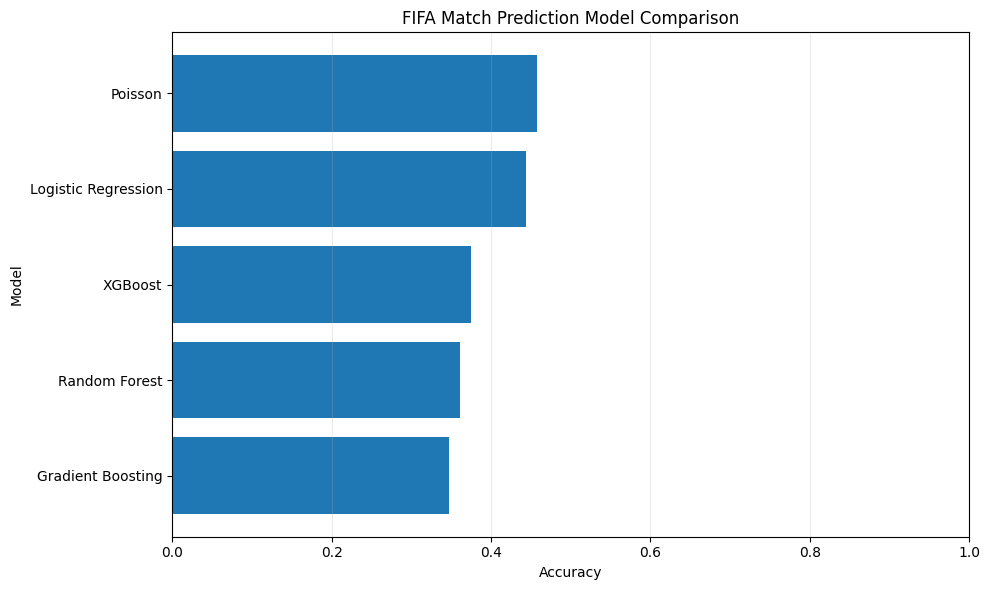

In [ ]:
import matplotlib.pyplot as plt

plot_df = five_model_results.sort_values(
    "Accuracy"
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["Model"],
    plot_df["Accuracy"]
)

plt.xlabel("Accuracy")
plt.ylabel("Model")

plt.title(
    "FIFA Match Prediction Model Comparison"
)

plt.xlim(0, 1)

plt.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()
plt.show()

In [ ]:
five_model_results.to_csv(
    "/content/sample_data/"
    "notebook4_five_model_results.csv",
    index=False
)

poisson_test.to_csv(
    "/content/sample_data/"
    "notebook4_poisson_test_predictions.csv",
    index=False
)

print("✓ Results saved to sample_data.")

✓ Results saved to sample_data.


In [ ]:
import os

DATA_DIR = "/content/sample_data"

CUP_PATH = os.path.join(DATA_DIR, "cup.txt")
FINALS_PATH = os.path.join(DATA_DIR, "cup_finals.txt")
QUALI_PATH = os.path.join(DATA_DIR, "quali_playoffs.txt")

files_2026 = {
    "Main World Cup": CUP_PATH,
    "Finals / Knockout": FINALS_PATH,
    "Qualification Playoffs": QUALI_PATH
}

print("=" * 70)
print("2026 WORLD CUP FILE CHECK")
print("=" * 70)

for name, path in files_2026.items():

    if os.path.exists(path):
        print(f"✓ {name}: {path}")

    else:
        print(f"✗ MISSING: {name}")
        print(f"  Expected: {path}")

2026 WORLD CUP FILE CHECK
✓ Main World Cup: /content/sample_data/cup.txt
✓ Finals / Knockout: /content/sample_data/cup_finals.txt
✓ Qualification Playoffs: /content/sample_data/quali_playoffs.txt


In [ ]:
with open(CUP_PATH, "r", encoding="utf-8") as f:
    cup_text = f.read()

with open(FINALS_PATH, "r", encoding="utf-8") as f:
    finals_text = f.read()

with open(QUALI_PATH, "r", encoding="utf-8") as f:
    quali_text = f.read()

print("Files loaded successfully.")

print("\ncup.txt characters:", len(cup_text))
print("cup_finals.txt characters:", len(finals_text))
print("quali_playoffs.txt characters:", len(quali_text))

Files loaded successfully.

cup.txt characters: 13838
cup_finals.txt characters: 6051
quali_playoffs.txt characters: 3782


In [ ]:
def useful_lines(text):
    lines = []

    for line in text.splitlines():

        stripped = line.strip()

        # remove blank lines
        if not stripped:
            continue

        # remove comments
        if stripped.startswith("#"):
            continue

        lines.append(line)

    return lines


cup_lines = useful_lines(cup_text)
finals_lines = useful_lines(finals_text)
quali_lines = useful_lines(quali_text)


print("=" * 70)
print("CUP.TXT")
print("=" * 70)

for line in cup_lines[:120]:
    print(line)


print("\n" + "=" * 70)
print("CUP_FINALS.TXT")
print("=" * 70)

for line in finals_lines[:80]:
    print(line)


print("\n" + "=" * 70)
print("QUALI_PLAYOFFS.TXT")
print("=" * 70)

for line in quali_lines[:80]:
    print(line)

CUP.TXT
= World Cup 2026      # in Canada, USA, and Mexico
Group A | Mexico        South Africa    South Korea    Czech Republic
Group B | Canada      Bosnia & Herzegovina  Qatar    Switzerland
Group C | Brazil          Morocco      Haiti   Scotland
Group D | USA   Paraguay     Australia   Turkey
Group E | Germany         Curaçao      Ivory Coast   Ecuador
Group F | Netherlands   Japan        Sweden  Tunisia
Group G | Belgium         Egypt        Iran        New Zealand
Group H | Spain           Cape Verde   Saudi Arabia   Uruguay
Group I | France      Senegal   Iraq   Norway
Group J | Argentina    Algeria   Austria   Jordan
Group K | Portugal   DR Congo   Uzbekistan  Colombia
Group L | England    Croatia     Ghana   Panama
▪ Matchday 1 | Thu Jun 11
▪ Matchday 2 | Fri Jun 12
▪ Matchday 3 | Sat Jun 13
▪ Matchday 4 | Sun Jun 14
▪ Matchday 5 | Mon Jun 15
▪ Matchday 6 | Tue Jun 16
▪ Matchday 7 | Wed Jun 17
▪ Matchday 8 | Thu Jun 18
▪ Matchday 9 | Fri Jun 19
▪ Matchday 10 | Sat Jun 20
▪ Mat

In [ ]:
import re
import pandas as pd
import numpy as np

group_matches = []

current_group = None
current_date = None

for raw_line in cup_text.splitlines():

    line = raw_line.strip()


    # Detect group

    group_match = re.match(
        r"▪\s*Group\s+([A-L])$",
        line
    )

    if group_match:
        current_group = group_match.group(1)
        continue

    # Detect match date

    date_match = re.match(
        r"(Mon|Tue|Wed|Thu|Fri|Sat|Sun)\s+"
        r"(June|Jun|July|Jul)\s+\d{1,2}",
        line
    )

    if date_match:
        current_date = line
        continue


    # Ignore lines before groups

    if current_group is None:
        continue

    if "@" not in line:
        continue

    before_venue = line.split("@")[0].strip()

    # remove time/timezone from beginning
    before_venue = re.sub(
        r"^\d{1,2}:\d{2}\s+"
        r"(?:UTC[+-]\d+|UTC±\d+)\s+",
        "",
        before_venue
    )

    # find full-time score
    score_match = re.search(
        r"\b(\d+)\s*-\s*(\d+)\b",
        before_venue
    )

    if not score_match:
        continue

    score_a = int(score_match.group(1))
    score_b = int(score_match.group(2))

    team_a = before_venue[
        :score_match.start()
    ].strip()

    remainder = before_venue[
        score_match.end():
    ].strip()

    # remove halftime score
    remainder = re.sub(
        r"^\s*\([^)]*\)\s*",
        "",
        remainder
    )

    team_b = remainder.strip()

    # safety
    if not team_a or not team_b:
        continue

    group_matches.append({
        "date_text": current_date,
        "stage": "Group Stage",
        "group": current_group,
        "team_a": team_a,
        "team_b": team_b,
        "score_a": score_a,
        "score_b": score_b
    })


wc2026_groups = pd.DataFrame(group_matches)

print("Group-stage matches parsed:", len(wc2026_groups))

display(
    wc2026_groups.head(20)
)

Group-stage matches parsed: 72


,date_text,stage,group,team_a,team_b,score_a,score_b
0,Thu June 11,Group Stage,A,Mexico,South Africa,2,0
1,Thu June 11,Group Stage,A,South Korea,Czech Republic,2,1
2,Thu June 18,Group Stage,A,Czech Republic,South Africa,1,1
3,Thu June 18,Group Stage,A,Mexico,South Korea,1,0
4,Wed June 24,Group Stage,A,Czech Republic,Mexico,0,3
5,Wed June 24,Group Stage,A,South Africa,South Korea,1,0
6,Fri June 12,Group Stage,B,Canada,Bosnia & Herzegovina,1,1
7,Sat June 13,Group Stage,B,Qatar,Switzerland,1,1
8,Thu June 18,Group Stage,B,Switzerland,Bosnia & Herzegovina,4,1
9,Thu June 18,Group Stage,B,Canada,Qatar,6,0


In [ ]:
print("=" * 60)
print("GROUP-STAGE PARSER CHECK")
print("=" * 60)

print("Matches:", len(wc2026_groups))

print(
    "Unique teams:",
    len(
        set(wc2026_groups["team_a"])
        |
        set(wc2026_groups["team_b"])
    )
)

print("\nMatches per group:")

print(
    wc2026_groups["group"]
    .value_counts()
    .sort_index()
)

print("\nFirst matches:")

display(
    wc2026_groups[
        [
            "group",
            "team_a",
            "score_a",
            "score_b",
            "team_b"
        ]
    ].head(12)
)

GROUP-STAGE PARSER CHECK
Matches: 72
Unique teams: 48

Matches per group:
group
A    6
B    6
C    6
D    6
E    6
F    6
G    6
H    6
I    6
J    6
K    6
L    6
Name: count, dtype: int64

First matches:


,group,team_a,score_a,score_b,team_b
0,A,Mexico,2,0,South Africa
1,A,South Korea,2,1,Czech Republic
2,A,Czech Republic,1,1,South Africa
3,A,Mexico,1,0,South Korea
4,A,Czech Republic,0,3,Mexico
5,A,South Africa,1,0,South Korea
6,B,Canada,1,1,Bosnia & Herzegovina
7,B,Qatar,1,1,Switzerland
8,B,Switzerland,4,1,Bosnia & Herzegovina
9,B,Canada,6,0,Qatar


In [ ]:
def result_from_score(score_a, score_b):

    if score_a > score_b:
        return 2

    elif score_a < score_b:
        return 0

    else:
        return 1


wc2026_groups["actual_target"] = (
    wc2026_groups.apply(
        lambda row: result_from_score(
            row["score_a"],
            row["score_b"]
        ),
        axis=1
    )
)

TARGET_TO_RESULT = {
    0: "Team B Win",
    1: "Draw",
    2: "Team A Win"
}

wc2026_groups["actual_result"] = (
    wc2026_groups["actual_target"]
    .map(TARGET_TO_RESULT)
)

display(
    wc2026_groups[
        [
            "group",
            "team_a",
            "team_b",
            "score_a",
            "score_b",
            "actual_result"
        ]
    ].head(20)
)

,group,team_a,team_b,score_a,score_b,actual_result
0,A,Mexico,South Africa,2,0,Team A Win
1,A,South Korea,Czech Republic,2,1,Team A Win
2,A,Czech Republic,South Africa,1,1,Draw
3,A,Mexico,South Korea,1,0,Team A Win
4,A,Czech Republic,Mexico,0,3,Team B Win
5,A,South Africa,South Korea,1,0,Team A Win
6,B,Canada,Bosnia & Herzegovina,1,1,Draw
7,B,Qatar,Switzerland,1,1,Draw
8,B,Switzerland,Bosnia & Herzegovina,4,1,Team A Win
9,B,Canada,Qatar,6,0,Team A Win


In [ ]:
teams_2026 = sorted(
    set(wc2026_groups["team_a"])
    |
    set(wc2026_groups["team_b"])
)

elo_teams = set(
    elo_df["team"]
    .astype(str)
    .str.strip()
)

missing_elo = [
    team
    for team in teams_2026
    if team not in elo_teams
]

print("2026 teams:", len(teams_2026))
print("Teams in ELO database:", len(elo_teams))

print("\n2026 teams missing an exact ELO match:")

if missing_elo:

    for team in missing_elo:
        print(" -", team)

else:
    print("✓ None")

2026 teams: 48
Teams in ELO database: 64

2026 teams missing an exact ELO match:
 - Bosnia & Herzegovina
 - Cape Verde
 - Curaçao
 - DR Congo
 - Haiti
 - Iraq
 - Ivory Coast
 - Jordan
 - Norway
 - Uzbekistan


In [ ]:
historical_teams = set(
    modeling_df["team_a"].astype(str).str.strip()
) | set(
    modeling_df["team_b"].astype(str).str.strip()
)

missing_history = [
    team
    for team in teams_2026
    if team not in historical_teams
]

print(
    "Historical teams:",
    len(historical_teams)
)

print(
    "\n2026 teams with no historical matches "
    "in our 358-match dataset:"
)

for team in missing_history:
    print(" -", team)

print(
    "\nTotal:",
    len(missing_history)
)

Historical teams: 64

2026 teams with no historical matches in our 358-match dataset:
 - Bosnia & Herzegovina
 - Cape Verde
 - Curaçao
 - DR Congo
 - Haiti
 - Iraq
 - Ivory Coast
 - Jordan
 - Norway
 - Uzbekistan

Total: 10


In [ ]:
knockout_matches = []

current_stage = None
current_date = None

stage_patterns = {
    "Round of 32": "Round of 32",
    "Round of 16": "Round of 16",
    "Quarter-final": "Quarter-final",
    "Semi-final": "Semi-final",
    "Third-place": "Third-place",
    "Final": "Final"
}

for raw_line in finals_text.splitlines():

    line = raw_line.strip()

    # Detect stage
    for text, stage_name in stage_patterns.items():

        if line.startswith("▪") and text in line:
            current_stage = stage_name
            break
    # Detect date
    if re.match(
        r"(Mon|Tue|Wed|Thu|Fri|Sat|Sun)\s+"
        r"(Jun|June|Jul|July)\s+\d{1,2}",
        line
    ):
        current_date = line
        continue

    if current_stage is None:
        continue

    if "@" not in line:
        continue

    # remove match number
    cleaned = re.sub(
        r"^\(\d+\)\s*",
        "",
        line
    )

    # remove time/timezone
    cleaned = re.sub(
        r"^\d{1,2}:\d{2}\s+"
        r"(?:UTC[+-]\d+|UTC±\d+)\s+",
        "",
        cleaned
    )

    before_venue = cleaned.split("@")[0].strip()

    # remove bracket comment
    before_venue = before_venue.split("##")[0].strip()

    # first score = official match score
    score_match = re.search(
        r"\b(\d+)\s*-\s*(\d+)\b",
        before_venue
    )

    if not score_match:
        continue

    team_a = before_venue[
        :score_match.start()
    ].strip()

    score_a = int(score_match.group(1))
    score_b = int(score_match.group(2))

    remainder = before_venue[
        score_match.end():
    ].strip()

    # detect penalties
    penalty_match = re.search(
        r"(\d+)\s*-\s*(\d+)\s*pen\.",
        remainder
    )

    pen_a = np.nan
    pen_b = np.nan

    if penalty_match:
        pen_a = int(penalty_match.group(1))
        pen_b = int(penalty_match.group(2))

    # remove everything describing ET/HT/penalties
    # team B is after the final metadata block.
    team_b = re.sub(
        r"^.*?(?:pen\.\s*)",
        "",
        remainder
    ) if penalty_match else remainder

    # remove a.e.t and parenthetical score information
    team_b = re.sub(
        r"^a\.e\.t\.\s*",
        "",
        team_b
    )

    team_b = re.sub(
        r"^\([^)]*\)\s*",
        "",
        team_b
    )

    team_b = team_b.strip(" ,")

    knockout_matches.append({
        "date_text": current_date,
        "stage": current_stage,
        "team_a": team_a,
        "team_b_raw": team_b,
        "score_a": score_a,
        "score_b": score_b,
        "pen_a": pen_a,
        "pen_b": pen_b
    })


wc2026_knockout_raw = pd.DataFrame(
    knockout_matches
)

print(
    "Knockout lines parsed:",
    len(wc2026_knockout_raw)
)

display(
    wc2026_knockout_raw.head(20)
)

Knockout lines parsed: 32


,date_text,stage,team_a,team_b_raw,score_a,score_b,pen_a,pen_b
0,Sun Jun 28,Round of 32,South Africa,Canada,0,1,NaN,NaN
1,Mon Jun 29,Round of 32,Germany,Paraguay,1,1,3.0,4.0
2,Mon Jun 29,Round of 32,Netherlands,Morocco,1,1,2.0,3.0
3,Mon Jun 29,Round of 32,Brazil,Japan,2,1,NaN,NaN
4,Tue Jun 30,Round of 32,France,Sweden,3,0,NaN,NaN
5,Tue Jun 30,Round of 32,Ivory Coast,Norway,1,2,NaN,NaN
6,Tue Jun 30,Round of 32,Mexico,Ecuador,2,0,NaN,NaN
7,Wed Jul 1,Round of 32,England,DR Congo,2,1,NaN,NaN
8,Wed Jul 1,Round of 32,USA,Bosnia & Herzegovina,2,0,NaN,NaN
9,Wed Jul 1,Round of 32,Belgium,Senegal,3,2,NaN,NaN


In [ ]:
# features describing one individual team
TEAM_FEATURE_PAIRS = {
    "form_points": ("form_points_a", "form_points_b"),
    "avg_goals_for": ("avg_goals_for_a", "avg_goals_for_b"),
    "avg_goals_against": (
        "avg_goals_against_a",
        "avg_goals_against_b"
    ),
    "avg_goal_diff": (
        "avg_goal_diff_a",
        "avg_goal_diff_b"
    ),
    "win_rate": (
        "win_rate_a",
        "win_rate_b"
    ),
    "recent_games": (
        "recent_games_a",
        "recent_games_b"
    )
}

# historical neutral defaults
neutral_profile = {}

for feature, (col_a, col_b) in TEAM_FEATURE_PAIRS.items():

    combined = pd.concat([
        modeling_df[col_a],
        modeling_df[col_b]
    ])

    neutral_profile[feature] = (
        pd.to_numeric(
            combined,
            errors="coerce"
        ).median()
    )


elo_median = pd.to_numeric(
    elo_df["elo_rating"],
    errors="coerce"
).median()


print("Neutral fallback profile:")
print("-" * 45)

print(
    "ELO:",
    round(elo_median, 2)
)

for feature, value in neutral_profile.items():

    print(
        feature,
        "->",
        round(value, 3)
    )

Neutral fallback profile:
---------------------------------------------
ELO: 1490.48
form_points -> 1.4
avg_goals_for -> 1.2
avg_goals_against -> 1.0
avg_goal_diff -> 0.0
win_rate -> 0.4
recent_games -> 5.0


In [ ]:
history_sorted = modeling_df.copy()

history_sorted["date"] = pd.to_datetime(
    history_sorted["date"],
    errors="coerce"
)

history_sorted = history_sorted.sort_values(
    "date"
)

team_profiles = {}


for _, row in history_sorted.iterrows():

    team_a = str(row["team_a"]).strip()
    team_b = str(row["team_b"]).strip()

    # team A profile
    team_profiles[team_a] = {
        "form_points": row["form_points_a"],
        "avg_goals_for": row["avg_goals_for_a"],
        "avg_goals_against": row["avg_goals_against_a"],
        "avg_goal_diff": row["avg_goal_diff_a"],
        "win_rate": row["win_rate_a"],
        "recent_games": row["recent_games_a"]
    }

    # team B profile
    team_profiles[team_b] = {
        "form_points": row["form_points_b"],
        "avg_goals_for": row["avg_goals_for_b"],
        "avg_goals_against": row["avg_goals_against_b"],
        "avg_goal_diff": row["avg_goal_diff_b"],
        "win_rate": row["win_rate_b"],
        "recent_games": row["recent_games_b"]
    }


print(
    "Historical team profiles created:",
    len(team_profiles)
)

Historical team profiles created: 64


In [ ]:
elo_lookup = dict(
    zip(
        elo_df["team"].astype(str).str.strip(),
        pd.to_numeric(
            elo_df["elo_rating"],
            errors="coerce"
        )
    )
)


def get_elo(team):

    if team in elo_lookup:
        return float(elo_lookup[team])

    return float(elo_median)


def get_profile(team):

    if team in team_profiles:
        return team_profiles[team].copy()

    return neutral_profile.copy()


print("ELO lookup ready.")
print("Profile lookup ready.")

ELO lookup ready.
Profile lookup ready.


In [ ]:
def create_match_features(
    team_a,
    team_b,
    is_knockout=0
):

    profile_a = get_profile(team_a)
    profile_b = get_profile(team_b)

    elo_a = get_elo(team_a)
    elo_b = get_elo(team_b)

    row = {
        "elo_a": elo_a,
        "elo_b": elo_b,
        "elo_diff": elo_a - elo_b,

        "form_points_a":
            profile_a["form_points"],

        "form_points_b":
            profile_b["form_points"],

        "form_diff":
            profile_a["form_points"]
            - profile_b["form_points"],

        "avg_goals_for_a":
            profile_a["avg_goals_for"],

        "avg_goals_for_b":
            profile_b["avg_goals_for"],

        "goals_for_diff":
            profile_a["avg_goals_for"]
            - profile_b["avg_goals_for"],

        "avg_goals_against_a":
            profile_a["avg_goals_against"],

        "avg_goals_against_b":
            profile_b["avg_goals_against"],

        "goals_against_diff":
            profile_a["avg_goals_against"]
            - profile_b["avg_goals_against"],

        "avg_goal_diff_a":
            profile_a["avg_goal_diff"],

        "avg_goal_diff_b":
            profile_b["avg_goal_diff"],

        "recent_goal_diff":
            profile_a["avg_goal_diff"]
            - profile_b["avg_goal_diff"],

        "win_rate_a":
            profile_a["win_rate"],

        "win_rate_b":
            profile_b["win_rate"],

        "win_rate_diff":
            profile_a["win_rate"]
            - profile_b["win_rate"],

        "recent_games_a":
            profile_a["recent_games"],

        "recent_games_b":
            profile_b["recent_games"],

        "is_knockout":
            int(is_knockout)
    }

    return row

In [ ]:
feature_rows = []

for _, match in wc2026_groups.iterrows():

    features = create_match_features(
        match["team_a"],
        match["team_b"],
        is_knockout=0
    )

    feature_rows.append(features)


X_2026_groups = pd.DataFrame(
    feature_rows
)

# Force exact training feature order
X_2026_groups = X_2026_groups[
    FEATURES
]


print(
    "2026 feature matrix:",
    X_2026_groups.shape
)

display(
    X_2026_groups.head()
)

2026 feature matrix: (72, 21)


,elo_a,elo_b,elo_diff,form_points_a,form_points_b,form_diff,avg_goals_for_a,avg_goals_for_b,goals_for_diff,avg_goals_against_a,avg_goals_against_b,goals_against_diff,avg_goal_diff_a,avg_goal_diff_b,recent_goal_diff,win_rate_a,win_rate_b,win_rate_diff,recent_games_a,recent_games_b,is_knockout
0,1507.156699,1500.000000,7.156699,0.8,0.5,0.3,0.4,0.5,-0.1,1.6,2.0,-0.4,-1.2,-1.5,0.3,0.2,0.0,0.2,5.0,2.0,0
1,1452.063671,1473.694038,-21.630367,1.4,0.8,0.6,1.4,1.0,0.4,1.2,1.2,0.0,0.2,-0.2,0.4,0.4,0.2,0.2,5.0,5.0,0
2,1473.694038,1500.000000,-26.305962,0.8,0.5,0.3,1.0,0.5,0.5,1.2,2.0,-0.8,-0.2,-1.5,1.3,0.2,0.0,0.2,5.0,2.0,0
3,1507.156699,1452.063671,55.093028,0.8,1.4,-0.6,0.4,1.4,-1.0,1.6,1.2,0.4,-1.2,0.2,-1.4,0.2,0.4,-0.2,5.0,5.0,0
4,1473.694038,1507.156699,-33.462661,0.8,0.8,0.0,1.0,0.4,0.6,1.2,1.6,-0.4,-0.2,-1.2,1.0,0.2,0.2,0.0,5.0,5.0,0


In [ ]:
wc2026_predictions = (
    wc2026_groups.copy()
)

# Logistic Regression
wc2026_predictions["Logistic"] = (
    logistic_model.predict(
        X_2026_groups
    )
)

# Random Forest
wc2026_predictions["Random_Forest"] = (
    rf_model.predict(
        X_2026_groups
    )
)

# Gradient Boosting
wc2026_predictions["Gradient_Boosting"] = (
    gb_model.predict(
        X_2026_groups
    )
)

# XGBoost
xgb_2026_encoded = (
    xgb_model.predict(
        X_2026_groups
    )
)

wc2026_predictions["XGBoost"] = (
    xgb_label_encoder.inverse_transform(
        xgb_2026_encoded.astype(int)
    )
)

print("Four classifier predictions complete.")

✓ Four classifier predictions complete.


In [ ]:
X_2026_poisson = X_2026_groups[
    POISSON_FEATURES
]

expected_goals_a = (
    poisson_model_a.predict(
        X_2026_poisson
    )
)

expected_goals_b = (
    poisson_model_b.predict(
        X_2026_poisson
    )
)

poisson_2026_predictions = []

poisson_2026_confidence = []

for lambda_a, lambda_b in zip(
    expected_goals_a,
    expected_goals_b
):

    prob_b, prob_draw, prob_a = (
        poisson_match_probabilities(
            lambda_a,
            lambda_b
        )
    )

    probabilities = [
        prob_b,
        prob_draw,
        prob_a
    ]

    poisson_2026_predictions.append(
        int(np.argmax(probabilities))
    )

    poisson_2026_confidence.append(
        max(probabilities)
    )


wc2026_predictions[
    "Poisson"
] = poisson_2026_predictions

wc2026_predictions[
    "Poisson_xG_A"
] = expected_goals_a

wc2026_predictions[
    "Poisson_xG_B"
] = expected_goals_b

wc2026_predictions[
    "Poisson_Confidence"
] = poisson_2026_confidence

print("Poisson predictions complete.")

✓ Poisson predictions complete.


In [ ]:
MODEL_COLUMNS = [
    "Logistic",
    "Random_Forest",
    "Gradient_Boosting",
    "XGBoost",
    "Poisson"
]


for model in MODEL_COLUMNS:

    wc2026_predictions[
        f"{model}_Result"
    ] = (
        wc2026_predictions[model]
        .map(TARGET_TO_RESULT)
    )

    wc2026_predictions[
        f"{model}_Correct"
    ] = (
        wc2026_predictions[model]
        ==
        wc2026_predictions[
            "actual_target"
        ]
    )


display(
    wc2026_predictions[
        [
            "group",
            "team_a",
            "team_b",
            "score_a",
            "score_b",
            "actual_result",
            "Logistic_Result",
            "Random_Forest_Result",
            "Gradient_Boosting_Result",
            "XGBoost_Result",
            "Poisson_Result"
        ]
    ].head(20)
)

,group,team_a,team_b,score_a,score_b,actual_result,Logistic_Result,Random_Forest_Result,Gradient_Boosting_Result,XGBoost_Result,Poisson_Result
0,A,Mexico,South Africa,2,0,Team A Win,Team A Win,Team B Win,Team B Win,Team B Win,Team A Win
1,A,South Korea,Czech Republic,2,1,Team A Win,Team B Win,Team B Win,Team B Win,Team B Win,Team A Win
2,A,Czech Republic,South Africa,1,1,Draw,Team A Win,Team B Win,Draw,Team A Win,Team A Win
3,A,Mexico,South Korea,1,0,Team A Win,Team B Win,Team A Win,Draw,Draw,Team B Win
4,A,Czech Republic,Mexico,0,3,Team B Win,Team B Win,Team B Win,Team A Win,Team B Win,Team B Win
5,A,South Africa,South Korea,1,0,Team A Win,Team B Win,Team B Win,Draw,Draw,Team B Win
6,B,Canada,Bosnia & Herzegovina,1,1,Draw,Team B Win,Team B Win,Team B Win,Team B Win,Team B Win
7,B,Qatar,Switzerland,1,1,Draw,Team B Win,Team B Win,Team B Win,Team B Win,Team B Win
8,B,Switzerland,Bosnia & Herzegovina,4,1,Team A Win,Team B Win,Draw,Team B Win,Team B Win,Team A Win
9,B,Canada,Qatar,6,0,Team A Win,Draw,Team B Win,Team A Win,Team B Win,Team B Win


In [ ]:
results_2026 = []

for model in MODEL_COLUMNS:

    accuracy = (
        wc2026_predictions[
            f"{model}_Correct"
        ].mean()
    )

    macro_f1 = f1_score(
        wc2026_predictions[
            "actual_target"
        ],
        wc2026_predictions[
            model
        ],
        average="macro"
    )

    correct = (
        wc2026_predictions[
            f"{model}_Correct"
        ].sum()
    )

    results_2026.append({
        "Model": model.replace("_", " "),
        "Correct": int(correct),
        "Total": len(wc2026_predictions),
        "Accuracy": accuracy,
        "Macro_F1": macro_f1
    })


results_2026_df = pd.DataFrame(
    results_2026
)

results_2026_df = (
    results_2026_df
    .sort_values(
        "Accuracy",
        ascending=False
    )
    .reset_index(drop=True)
)

display(results_2026_df)

,Model,Correct,Total,Accuracy,Macro_F1
0,Poisson,40,72,0.555556,0.426304
1,Gradient Boosting,30,72,0.416667,0.400508
2,Logistic,28,72,0.388889,0.373964
3,Random Forest,26,72,0.361111,0.330640
4,XGBoost,25,72,0.347222,0.315520


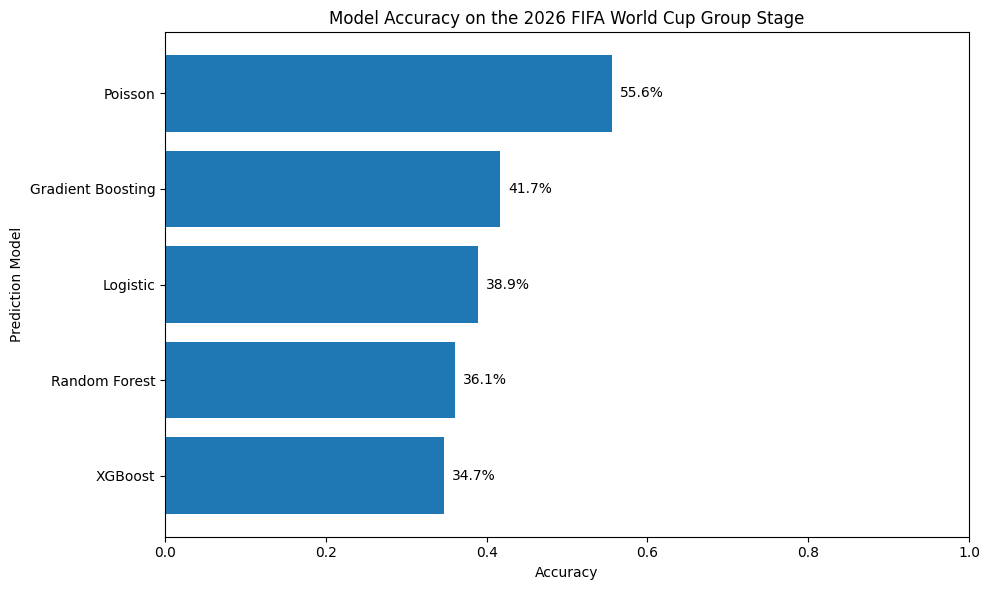

In [ ]:
plot_2026 = (
    results_2026_df
    .sort_values("Accuracy")
)

plt.figure(
    figsize=(10, 6)
)

bars = plt.barh(
    plot_2026["Model"],
    plot_2026["Accuracy"]
)

plt.xlabel(
    "Accuracy"
)

plt.ylabel(
    "Prediction Model"
)

plt.title(
    "Model Accuracy on the 2026 FIFA World Cup Group Stage"
)

plt.xlim(0, 1)

for bar in bars:

    value = bar.get_width()

    plt.text(
        value + 0.01,
        bar.get_y()
        + bar.get_height() / 2,
        f"{value:.1%}",
        va="center"
    )

plt.tight_layout()

plt.show()

In [ ]:
BEST_2026_MODEL = (
    results_2026_df
    .iloc[0]["Model"]
    .replace(" ", "_")
)

print(
    "Best 2026 model:",
    BEST_2026_MODEL
)

wrong_matches = (
    wc2026_predictions[
        ~wc2026_predictions[
            f"{BEST_2026_MODEL}_Correct"
        ]
    ]
)

display(
    wrong_matches[
        [
            "group",
            "team_a",
            "team_b",
            "score_a",
            "score_b",
            "actual_result",
            f"{BEST_2026_MODEL}_Result"
        ]
    ]
)

Best 2026 model: Poisson


,group,team_a,team_b,score_a,score_b,actual_result,Poisson_Result
2,A,Czech Republic,South Africa,1,1,Draw,Team A Win
3,A,Mexico,South Korea,1,0,Team A Win,Team B Win
5,A,South Africa,South Korea,1,0,Team A Win,Team B Win
6,B,Canada,Bosnia & Herzegovina,1,1,Draw,Team B Win
7,B,Qatar,Switzerland,1,1,Draw,Team B Win
9,B,Canada,Qatar,6,0,Team A Win,Team B Win
12,C,Brazil,Morocco,1,1,Draw,Team A Win
13,C,Haiti,Scotland,0,1,Team B Win,Team A Win
18,D,USA,Paraguay,4,1,Team A Win,Team B Win
19,D,Australia,Turkey,2,0,Team A Win,Team B Win


In [ ]:
wc2026_predictions.to_csv(
    "/content/sample_data/"
    "2026_group_stage_model_predictions.csv",
    index=False
)

results_2026_df.to_csv(
    "/content/sample_data/"
    "2026_group_stage_model_accuracy.csv",
    index=False
)

wc2026_knockout_raw.to_csv(
    "/content/sample_data/"
    "2026_knockout_results_parsed.csv",
    index=False
)

print("✓ Saved:")
print(
    "2026_group_stage_model_predictions.csv"
)

print(
    "2026_group_stage_model_accuracy.csv"
)

print(
    "2026_knockout_results_parsed.csv"
)

✓ Saved:
2026_group_stage_model_predictions.csv
2026_group_stage_model_accuracy.csv
2026_knockout_results_parsed.csv


One methodological point to document in the capstone: those 10 unseen 2026 teams are being assigned neutral historical feature values rather than being removed. That is a real limitation of training only on your 358 World Cup/Euro matches, and it's actually useful to discuss because it shows why a future version should incorporate broader international-match histories.

In [ ]:
wc2026_knockout = (
    wc2026_knockout_raw
    .rename(
        columns={
            "team_b_raw": "team_b"
        }
    )
    .copy()
)

wc2026_knockout["team_a"] = (
    wc2026_knockout["team_a"]
    .astype(str)
    .str.strip()
)

wc2026_knockout["team_b"] = (
    wc2026_knockout["team_b"]
    .astype(str)
    .str.strip()
)

print("Knockout matches:", len(wc2026_knockout))

print("\nMatches per round:")
print(
    wc2026_knockout["stage"]
    .value_counts()
)

display(
    wc2026_knockout[
        [
            "stage",
            "team_a",
            "score_a",
            "score_b",
            "team_b",
            "pen_a",
            "pen_b"
        ]
    ]
)

Knockout matches: 32

Matches per round:
stage
Round of 32      16
Round of 16       8
Quarter-final     4
Semi-final        3
Final             1
Name: count, dtype: int64


,stage,team_a,score_a,score_b,team_b,pen_a,pen_b
0,Round of 32,South Africa,0,1,Canada,NaN,NaN
1,Round of 32,Germany,1,1,Paraguay,3.0,4.0
2,Round of 32,Netherlands,1,1,Morocco,2.0,3.0
3,Round of 32,Brazil,2,1,Japan,NaN,NaN
4,Round of 32,France,3,0,Sweden,NaN,NaN
5,Round of 32,Ivory Coast,1,2,Norway,NaN,NaN
6,Round of 32,Mexico,2,0,Ecuador,NaN,NaN
7,Round of 32,England,2,1,DR Congo,NaN,NaN
8,Round of 32,USA,2,0,Bosnia & Herzegovina,NaN,NaN
9,Round of 32,Belgium,3,2,Senegal,NaN,NaN


In [ ]:
wc2026_knockout["actual_target"] = (
    wc2026_knockout.apply(
        lambda row: result_from_score(
            row["score_a"],
            row["score_b"]
        ),
        axis=1
    )
)

wc2026_knockout["actual_result"] = (
    wc2026_knockout["actual_target"]
    .map(TARGET_TO_RESULT)
)


def determine_advancing_team(row):

    # normal / extra-time winner
    if row["score_a"] > row["score_b"]:
        return row["team_a"]

    if row["score_b"] > row["score_a"]:
        return row["team_b"]

    # penalty shootout
    if pd.notna(row["pen_a"]) and pd.notna(row["pen_b"]):

        if row["pen_a"] > row["pen_b"]:
            return row["team_a"]

        return row["team_b"]

    return np.nan


wc2026_knockout["actual_advancing_team"] = (
    wc2026_knockout.apply(
        determine_advancing_team,
        axis=1
    )
)

display(
    wc2026_knockout[
        [
            "stage",
            "team_a",
            "team_b",
            "score_a",
            "score_b",
            "pen_a",
            "pen_b",
            "actual_result",
            "actual_advancing_team"
        ]
    ]
)

,stage,team_a,team_b,score_a,score_b,pen_a,pen_b,actual_result,actual_advancing_team
0,Round of 32,South Africa,Canada,0,1,NaN,NaN,Team B Win,Canada
1,Round of 32,Germany,Paraguay,1,1,3.0,4.0,Draw,Paraguay
2,Round of 32,Netherlands,Morocco,1,1,2.0,3.0,Draw,Morocco
3,Round of 32,Brazil,Japan,2,1,NaN,NaN,Team A Win,Brazil
4,Round of 32,France,Sweden,3,0,NaN,NaN,Team A Win,France
5,Round of 32,Ivory Coast,Norway,1,2,NaN,NaN,Team B Win,Norway
6,Round of 32,Mexico,Ecuador,2,0,NaN,NaN,Team A Win,Mexico
7,Round of 32,England,DR Congo,2,1,NaN,NaN,Team A Win,England
8,Round of 32,USA,Bosnia & Herzegovina,2,0,NaN,NaN,Team A Win,USA
9,Round of 32,Belgium,Senegal,3,2,NaN,NaN,Team A Win,Belgium


In [ ]:
knockout_feature_rows = []

for _, match in wc2026_knockout.iterrows():

    features = create_match_features(
        match["team_a"],
        match["team_b"],
        is_knockout=1
    )

    knockout_feature_rows.append(
        features
    )


X_2026_knockout = pd.DataFrame(
    knockout_feature_rows
)

X_2026_knockout = (
    X_2026_knockout[FEATURES]
)

print(
    "Knockout feature matrix:",
    X_2026_knockout.shape
)

Knockout feature matrix: (32, 21)


In [ ]:
knockout_predictions = (
    wc2026_knockout.copy()
)

# Logistic
knockout_predictions["Logistic"] = (
    logistic_model.predict(
        X_2026_knockout
    )
)

# Random Forest
knockout_predictions["Random_Forest"] = (
    rf_model.predict(
        X_2026_knockout
    )
)

# Gradient Boosting
knockout_predictions["Gradient_Boosting"] = (
    gb_model.predict(
        X_2026_knockout
    )
)

# XGBoost
xgb_knockout_encoded = (
    xgb_model.predict(
        X_2026_knockout
    )
)

knockout_predictions["XGBoost"] = (
    xgb_label_encoder.inverse_transform(
        xgb_knockout_encoded.astype(int)
    )
)

# Poisson

X_knockout_poisson = (
    X_2026_knockout[
        POISSON_FEATURES
    ]
)

knockout_xg_a = (
    poisson_model_a.predict(
        X_knockout_poisson
    )
)

knockout_xg_b = (
    poisson_model_b.predict(
        X_knockout_poisson
    )
)

poisson_knockout = []

for lambda_a, lambda_b in zip(
    knockout_xg_a,
    knockout_xg_b
):

    prob_b, prob_draw, prob_a = (
        poisson_match_probabilities(
            lambda_a,
            lambda_b
        )
    )

    poisson_knockout.append(
        int(
            np.argmax(
                [
                    prob_b,
                    prob_draw,
                    prob_a
                ]
            )
        )
    )


knockout_predictions["Poisson"] = (
    poisson_knockout
)

knockout_predictions[
    "Poisson_xG_A"
] = knockout_xg_a

knockout_predictions[
    "Poisson_xG_B"
] = knockout_xg_b

print("Knockout predictions complete.")

✓ Knockout predictions complete.


In [ ]:
knockout_results = []

for model in MODEL_COLUMNS:

    pred = knockout_predictions[model]

    actual = knockout_predictions[
        "actual_target"
    ]

    accuracy = accuracy_score(
        actual,
        pred
    )

    macro_f1 = f1_score(
        actual,
        pred,
        average="macro"
    )

    correct = (
        pred == actual
    ).sum()

    knockout_results.append({
        "Model": model.replace("_", " "),
        "Correct": int(correct),
        "Total": len(actual),
        "Accuracy": accuracy,
        "Macro_F1": macro_f1
    })


knockout_results_df = (
    pd.DataFrame(knockout_results)
    .sort_values(
        "Accuracy",
        ascending=False
    )
    .reset_index(drop=True)
)

display(knockout_results_df)

,Model,Correct,Total,Accuracy,Macro_F1
0,Gradient Boosting,24,32,0.75000,0.629570
1,Poisson,23,32,0.71875,0.511312
2,Random Forest,20,32,0.62500,0.532906
3,XGBoost,20,32,0.62500,0.534728
4,Logistic,18,32,0.56250,0.496032


In [ ]:
group_eval = (
    wc2026_predictions.copy()
)

knockout_eval = (
    knockout_predictions.copy()
)

all_2026 = pd.concat(
    [
        group_eval,
        knockout_eval
    ],
    ignore_index=True
)

print(
    "Total 2026 matches:",
    len(all_2026)
)

assert len(all_2026) == 104

print(
    " Complete 104-match tournament assembled."
)

Total 2026 matches: 104
✓ Complete 104-match tournament assembled.


In [ ]:
final_results = []

for model in MODEL_COLUMNS:

    actual = (
        all_2026["actual_target"]
    )

    predicted = (
        all_2026[model]
    )

    correct = (
        predicted == actual
    ).sum()

    accuracy = accuracy_score(
        actual,
        predicted
    )

    macro_f1 = f1_score(
        actual,
        predicted,
        average="macro"
    )

    final_results.append({
        "Model": model.replace("_", " "),
        "Correct": int(correct),
        "Total": len(actual),
        "Accuracy": accuracy,
        "Macro_F1": macro_f1
    })


final_2026_results = (
    pd.DataFrame(final_results)
    .sort_values(
        "Accuracy",
        ascending=False
    )
    .reset_index(drop=True)
)

final_2026_results[
    "Accuracy_Percent"
] = (
    final_2026_results[
        "Accuracy"
    ] * 100
).round(2)

display(final_2026_results)

,Model,Correct,Total,Accuracy,Macro_F1,Accuracy_Percent
0,Poisson,63,104,0.605769,0.454638,60.58
1,Gradient Boosting,54,104,0.519231,0.481004,51.92
2,Logistic,46,104,0.442308,0.426279,44.23
3,Random Forest,46,104,0.442308,0.395831,44.23
4,XGBoost,45,104,0.432692,0.385430,43.27


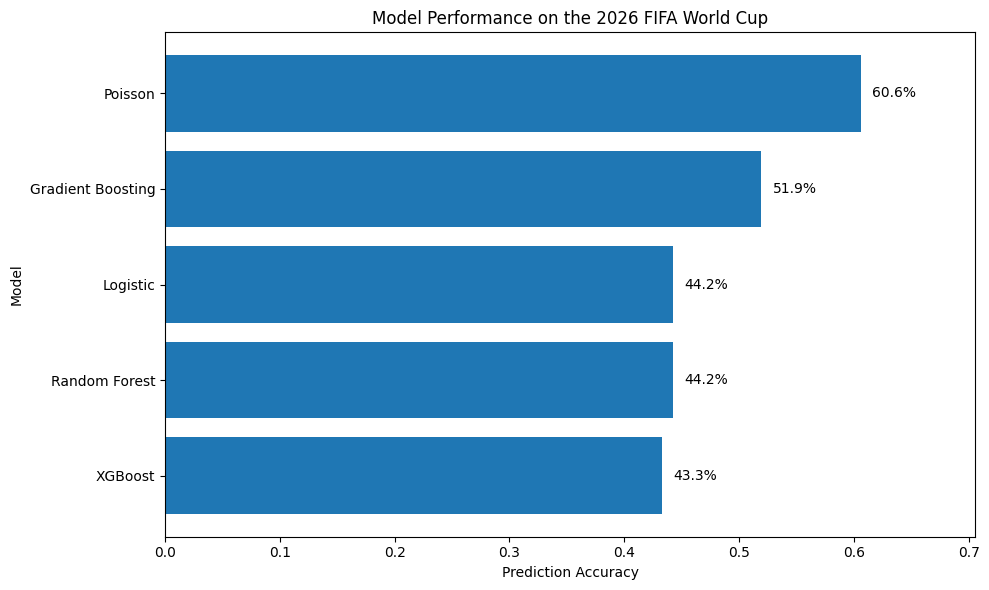

In [ ]:
plot_final = (
    final_2026_results
    .sort_values("Accuracy")
)

plt.figure(
    figsize=(10, 6)
)

bars = plt.barh(
    plot_final["Model"],
    plot_final["Accuracy"]
)

plt.xlabel(
    "Prediction Accuracy"
)

plt.ylabel(
    "Model"
)

plt.title(
    "Model Performance on the 2026 FIFA World Cup"
)

plt.xlim(
    0,
    max(
        0.7,
        plot_final["Accuracy"].max() + 0.1
    )
)

for bar in bars:

    accuracy = bar.get_width()

    plt.text(
        accuracy + 0.01,
        bar.get_y()
        + bar.get_height() / 2,
        f"{accuracy:.1%}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [ ]:
stage_comparison = (
    results_2026_df[
        [
            "Model",
            "Accuracy"
        ]
    ]
    .rename(
        columns={
            "Accuracy":
            "Group_Stage_Accuracy"
        }
    )
    .merge(
        knockout_results_df[
            [
                "Model",
                "Accuracy"
            ]
        ].rename(
            columns={
                "Accuracy":
                "Knockout_Accuracy"
            }
        ),
        on="Model"
    )
    .merge(
        final_2026_results[
            [
                "Model",
                "Accuracy"
            ]
        ].rename(
            columns={
                "Accuracy":
                "Overall_Accuracy"
            }
        ),
        on="Model"
    )
)

stage_comparison[
    [
        "Group_Stage_Accuracy",
        "Knockout_Accuracy",
        "Overall_Accuracy"
    ]
] = (
    stage_comparison[
        [
            "Group_Stage_Accuracy",
            "Knockout_Accuracy",
            "Overall_Accuracy"
        ]
    ].round(3)
)

display(stage_comparison)

,Model,Group_Stage_Accuracy,Knockout_Accuracy,Overall_Accuracy
0,Poisson,0.556,0.719,0.606
1,Gradient Boosting,0.417,0.750,0.519
2,Logistic,0.389,0.562,0.442
3,Random Forest,0.361,0.625,0.442
4,XGBoost,0.347,0.625,0.433


In [ ]:
knockout_predictions.to_csv(
    "/content/sample_data/"
    "2026_knockout_model_predictions.csv",
    index=False
)

all_2026.to_csv(
    "/content/sample_data/"
    "2026_all_104_model_predictions.csv",
    index=False
)

final_2026_results.to_csv(
    "/content/sample_data/"
    "2026_final_model_comparison.csv",
    index=False
)

stage_comparison.to_csv(
    "/content/sample_data/"
    "2026_group_vs_knockout_comparison.csv",
    index=False
)

print("=" * 60)
print("NOTEBOOK 4 COMPLETE")
print("=" * 60)

print("\n✓ 72 group-stage matches")
print("✓ 32 knockout matches")
print("✓ 104 total matches")
print("✓ 5 models evaluated")

print("\nBEST MODEL:")

display(
    final_2026_results.head(1)
)

NOTEBOOK 4 COMPLETE

✓ 72 group-stage matches
✓ 32 knockout matches
✓ 104 total matches
✓ 5 models evaluated

BEST MODEL:


,Model,Correct,Total,Accuracy,Macro_F1,Accuracy_Percent
0,Poisson,63,104,0.605769,0.454638,60.58


Poisson has the highest accuracy, while Gradient Boosting has the highest Macro F1. So Poisson is best at getting the greatest number of matches correct overall, while Gradient Boosting is somewhat better balanced across Team A wins, draws, and Team B wins.
My main capstone finding is that the football-specific Poisson approach generalized better to the 2026 tournament than the four classification models, reaching 60.58% accuracy. The more complex XGBoost model actually performed worst at 43.27%, showing that additional model complexity did not guarantee better out-of-sample prediction.

In [ ]:
country_rows = []

for _, row in all_2026.iterrows():

    # Team A
    country_rows.append({
        "country": row["team_a"],
        "actual_goals": row["score_a"],
        "predicted_goals": row["Poisson_xG_A"]
    })

    # Team B
    country_rows.append({
        "country": row["team_b"],
        "actual_goals": row["score_b"],
        "predicted_goals": row["Poisson_xG_B"]
    })


country_poisson = pd.DataFrame(country_rows)

# number each country's matches chronologically
country_poisson["match_number"] = (
    country_poisson
    .groupby("country")
    .cumcount() + 1
)

print(
    "Countries:",
    country_poisson["country"].nunique()
)

display(country_poisson.head(20))

Countries: 48


,country,actual_goals,predicted_goals,match_number
0,Mexico,2,1.248827,1
1,South Africa,0,1.231378,1
2,South Korea,2,1.291720,1
3,Czech Republic,1,1.267044,1
4,Czech Republic,1,1.199576,2
5,South Africa,1,1.160892,2
6,Mexico,1,1.171520,2
7,South Korea,0,1.334152,2
8,Czech Republic,0,1.158104,3
9,Mexico,3,1.190142,3


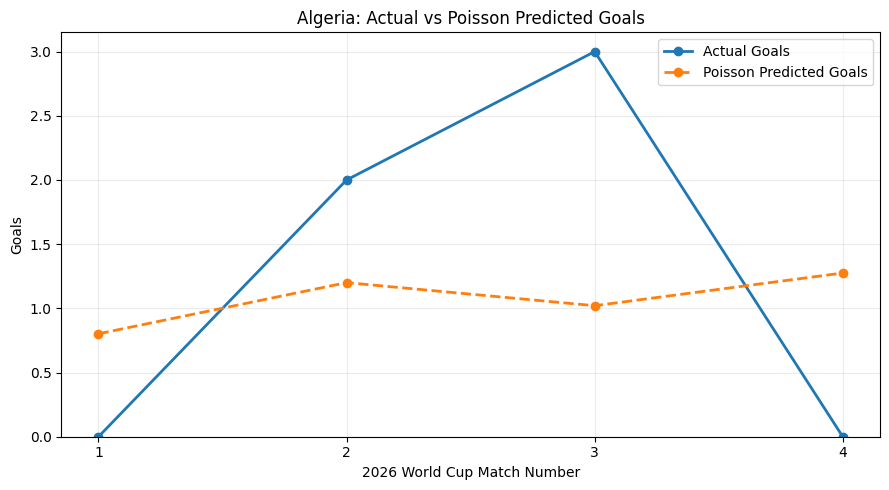

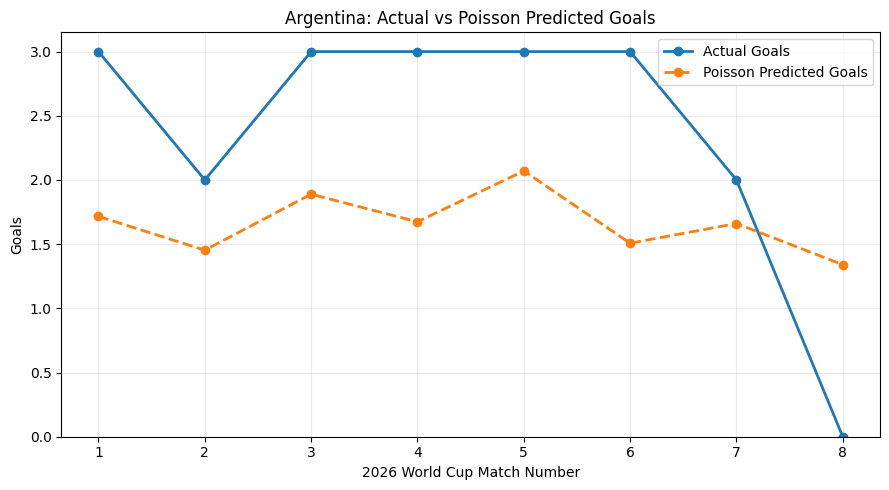

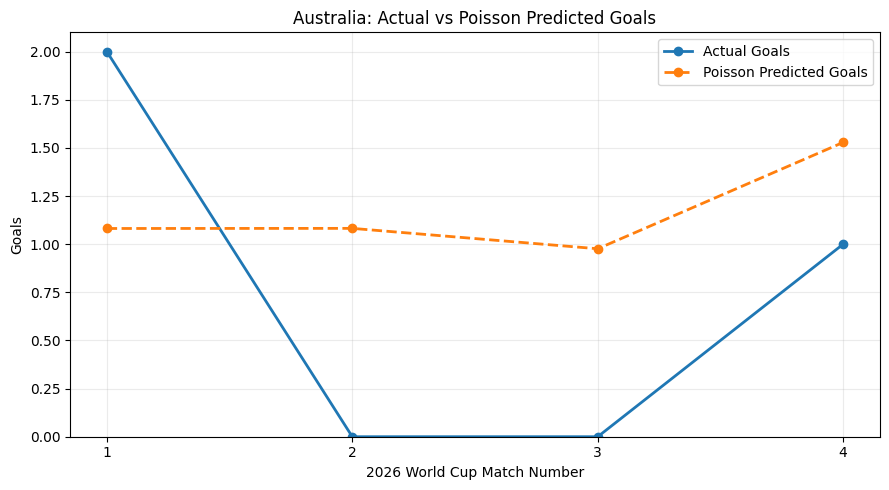

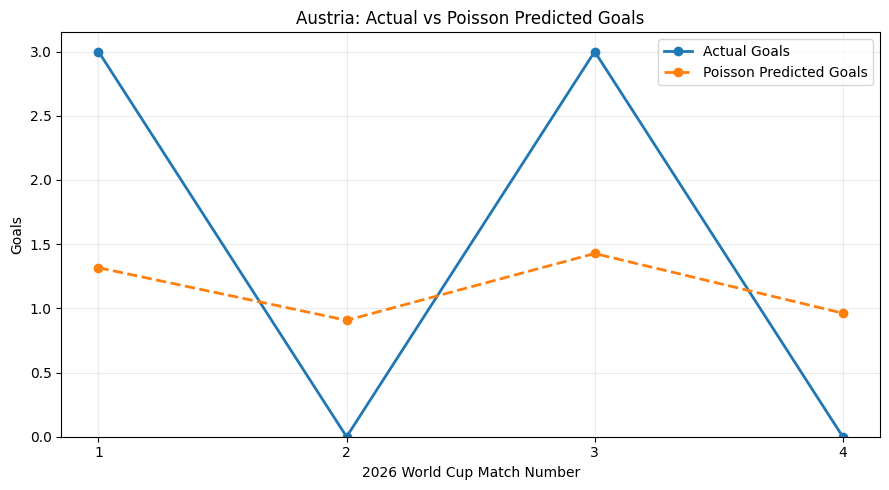

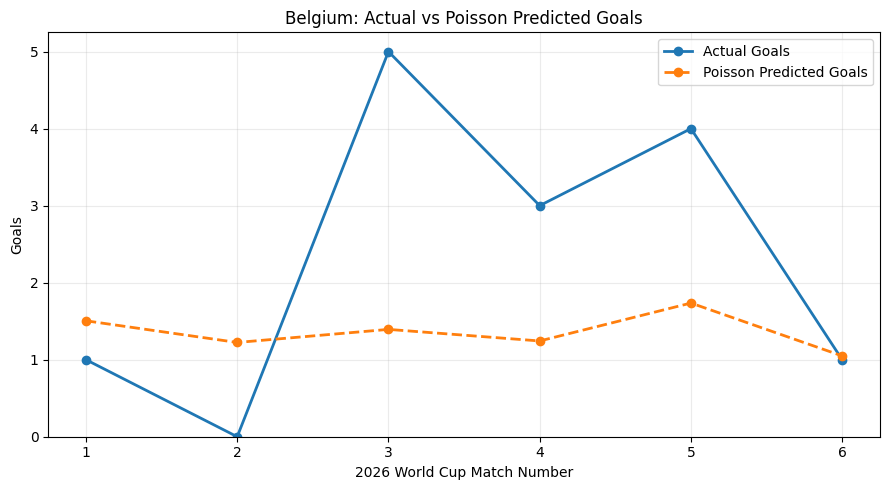

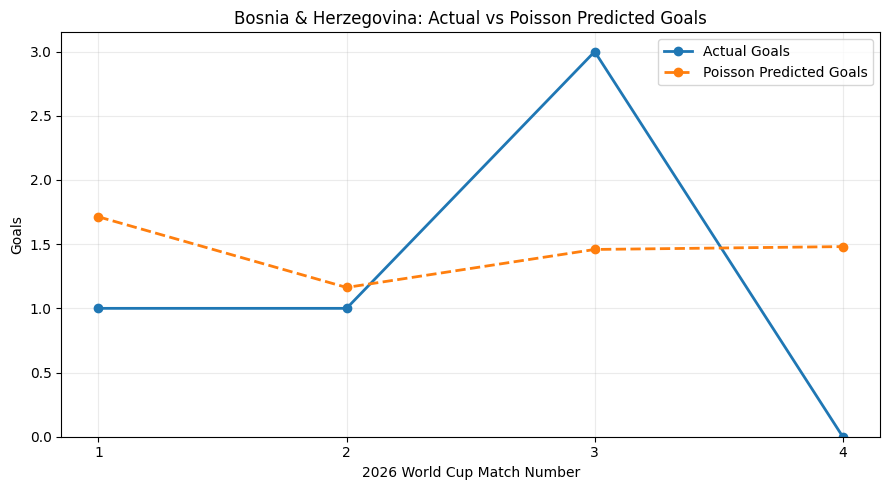

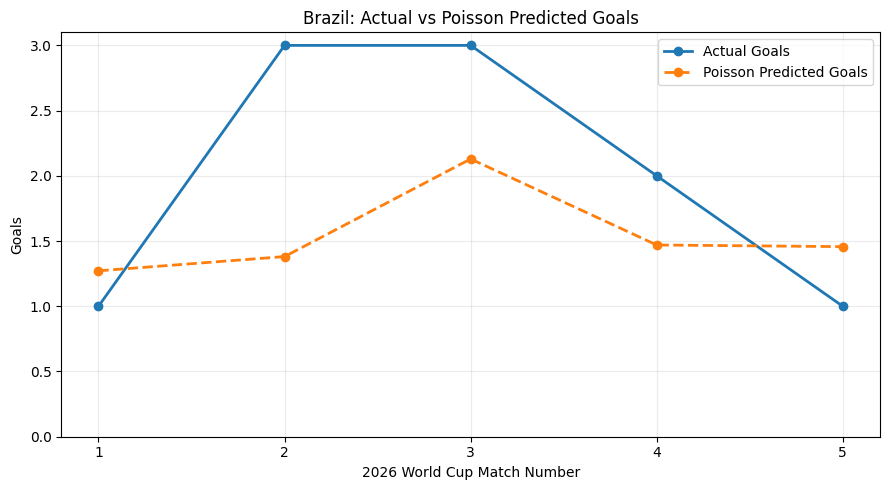

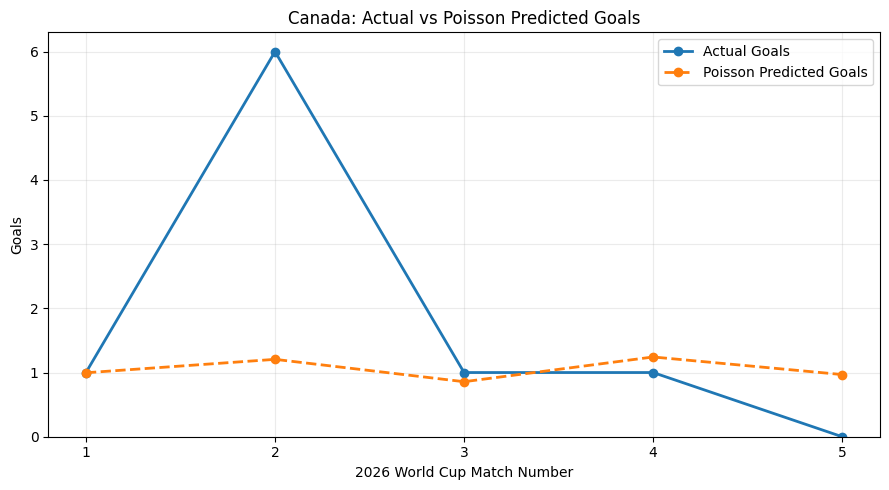

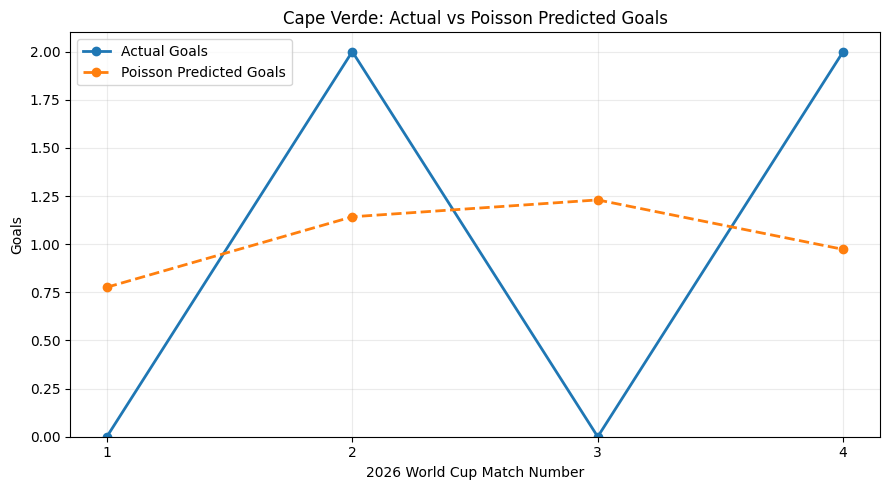

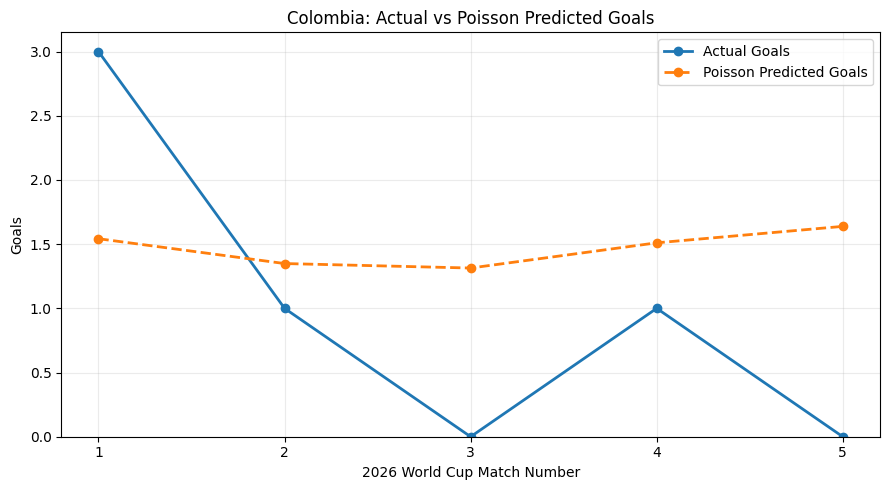

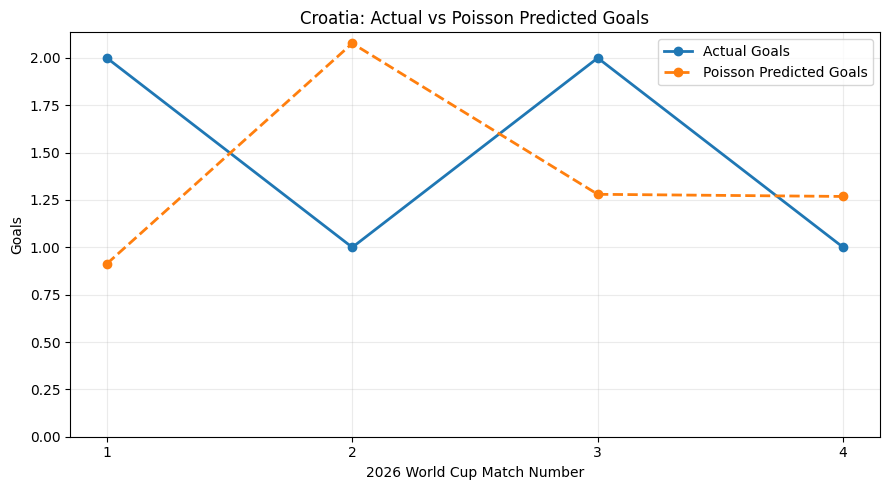

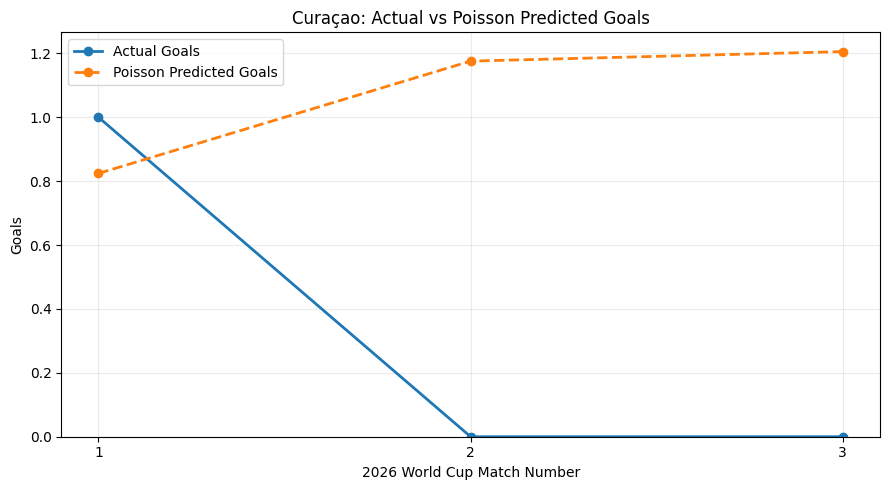

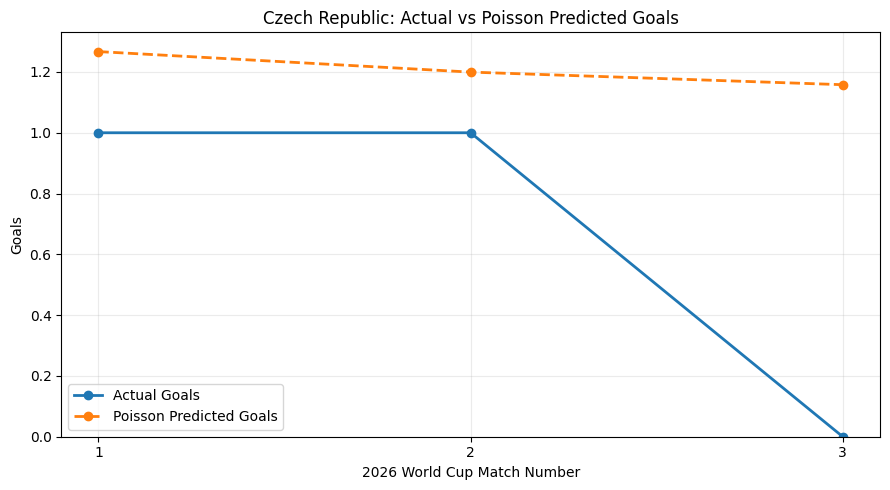

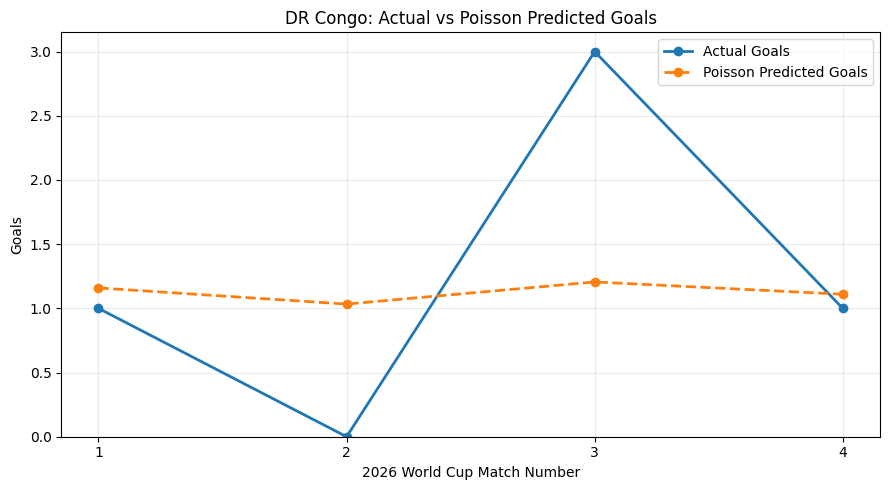

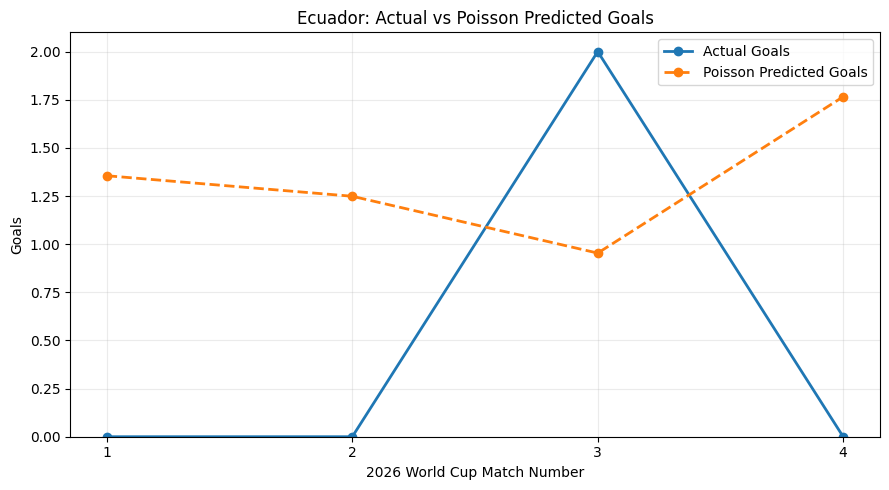

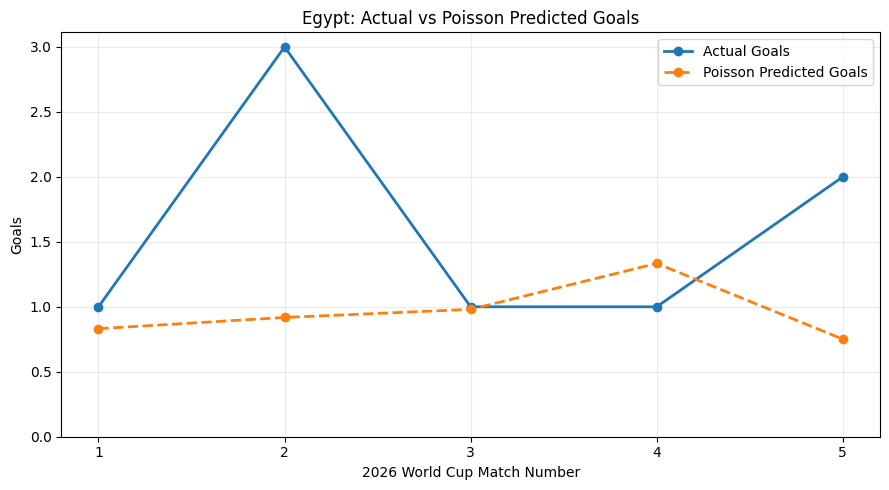

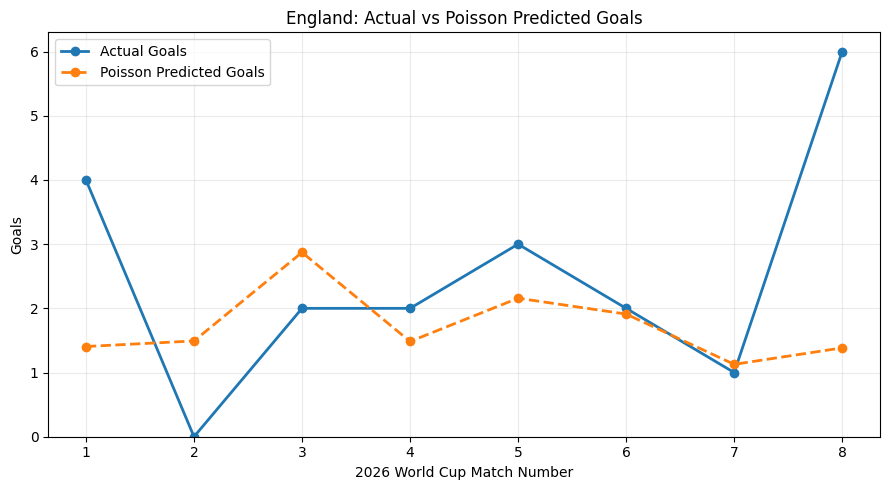

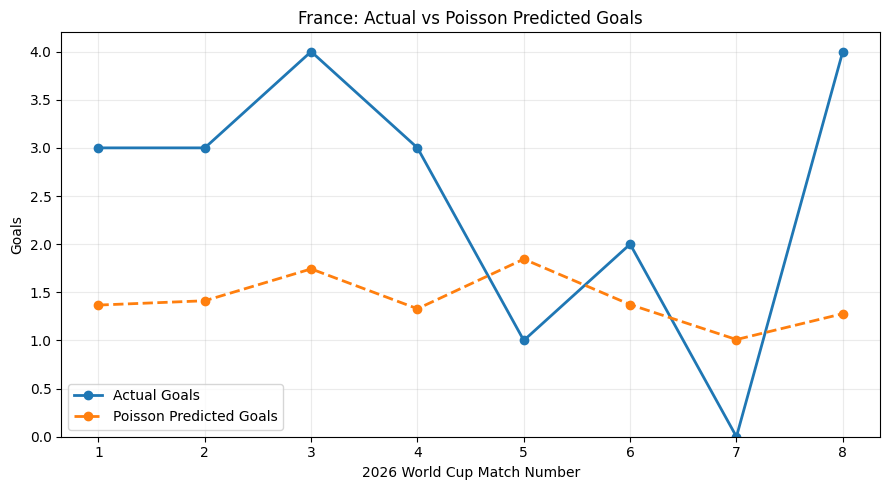

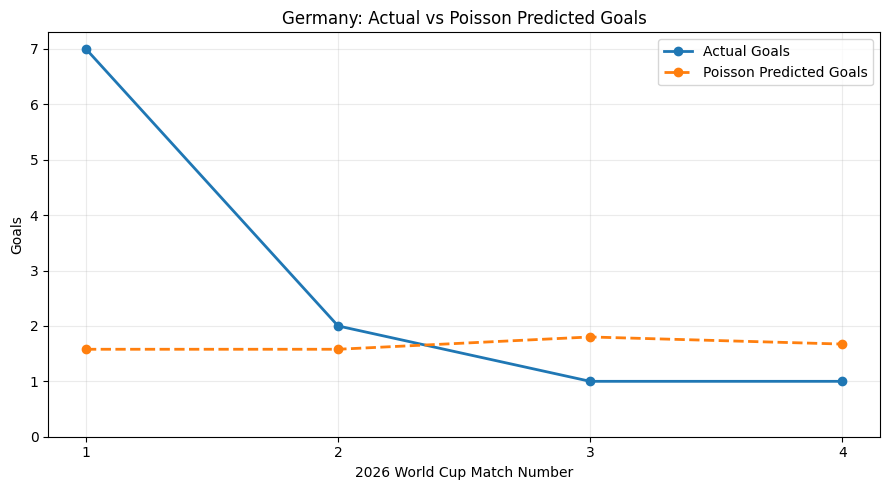

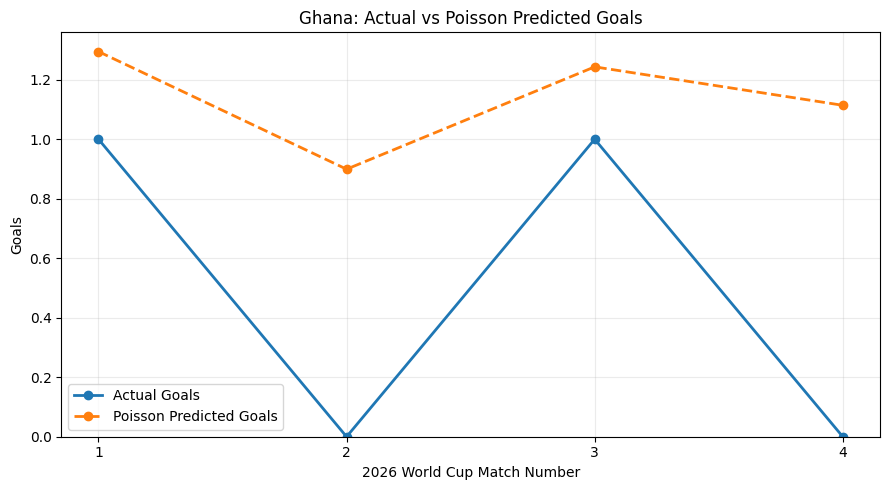

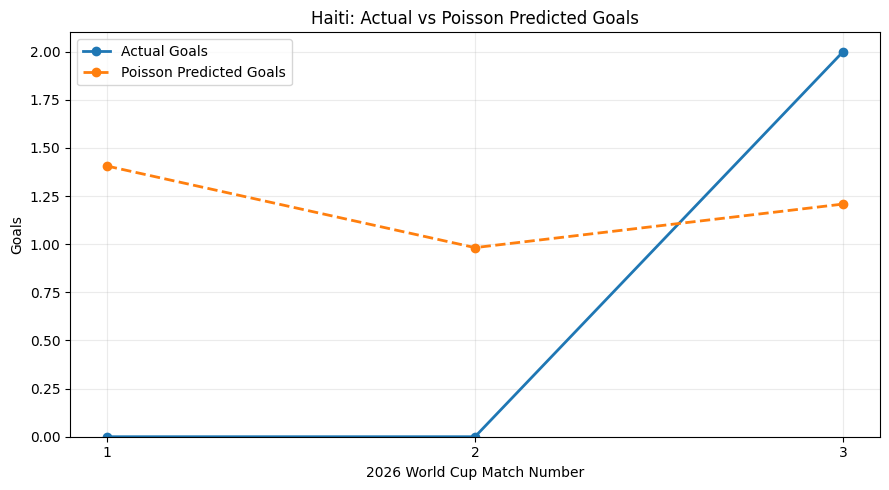

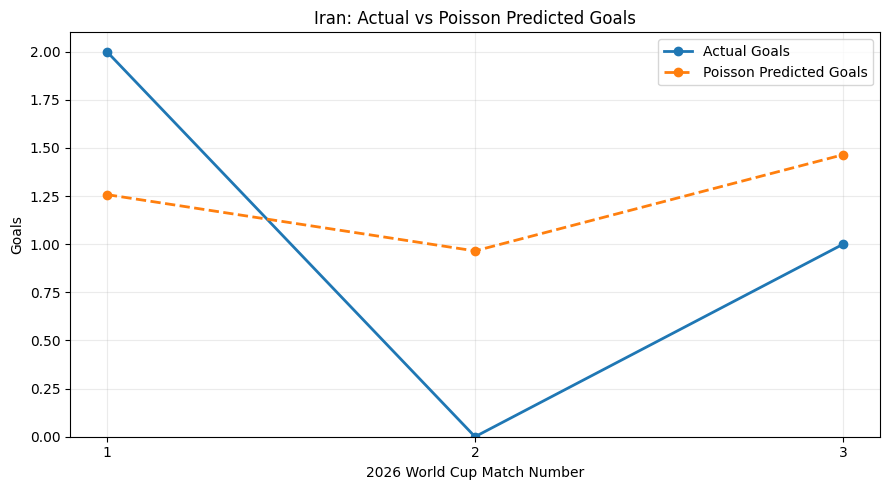

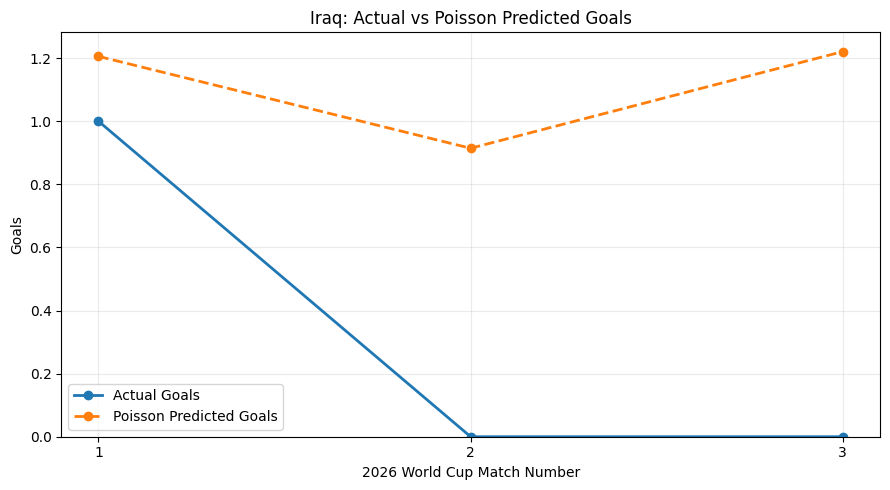

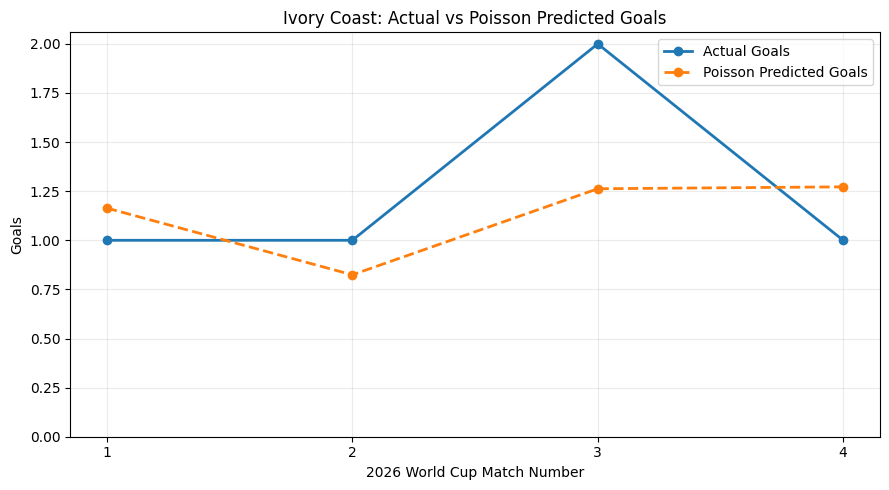

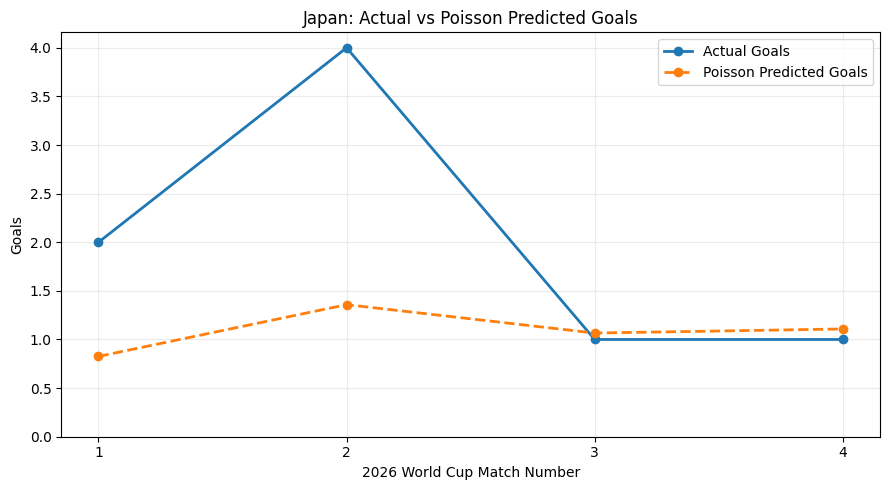

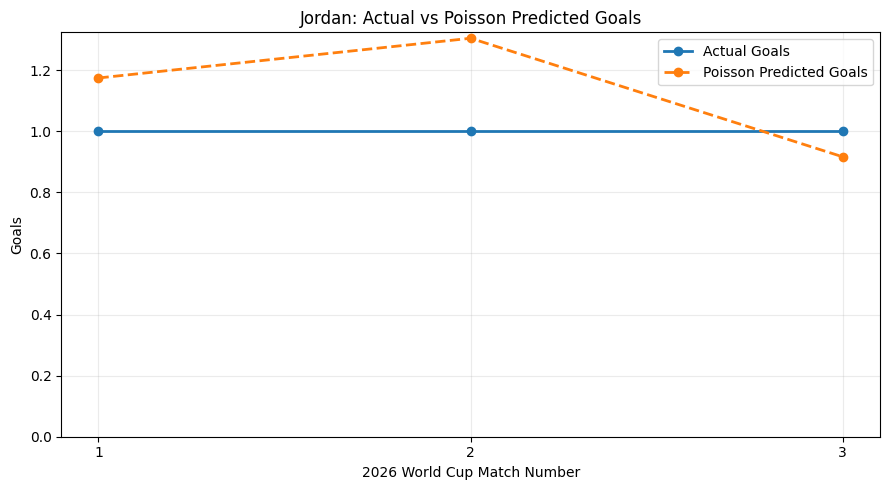

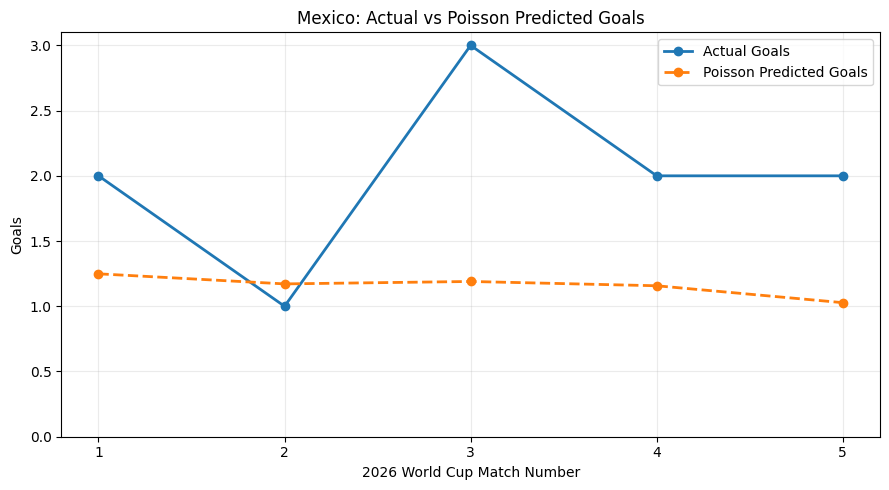

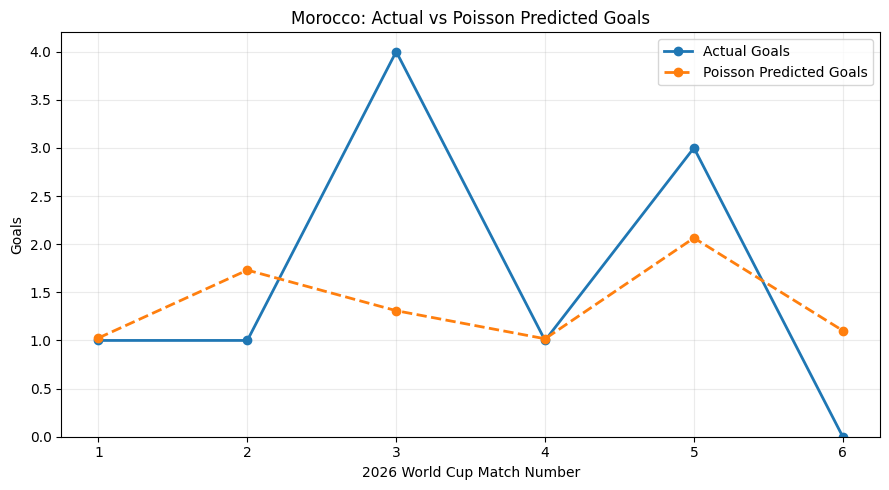

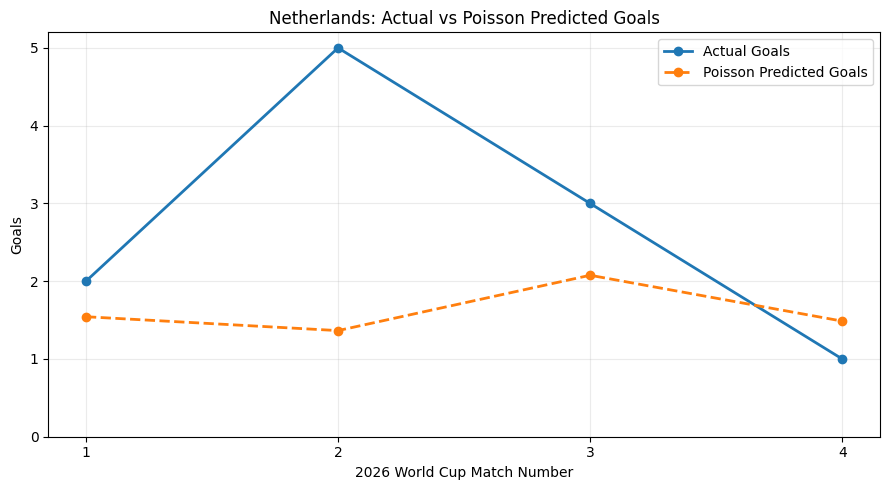

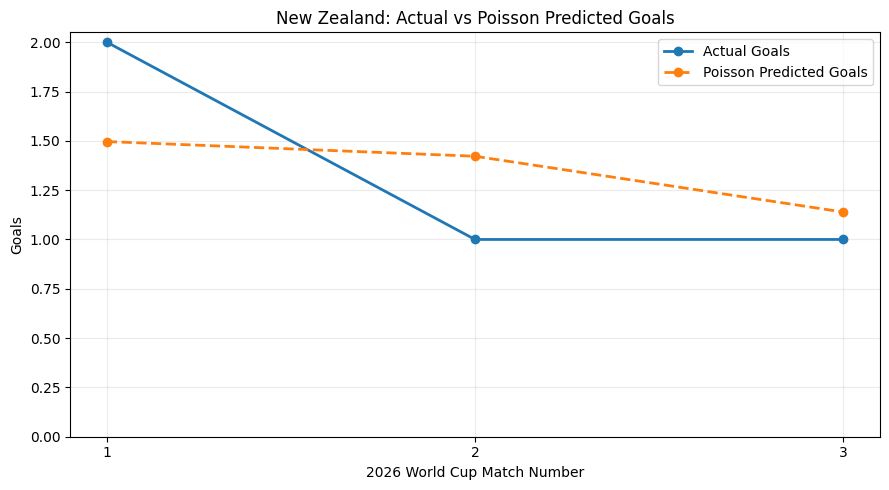

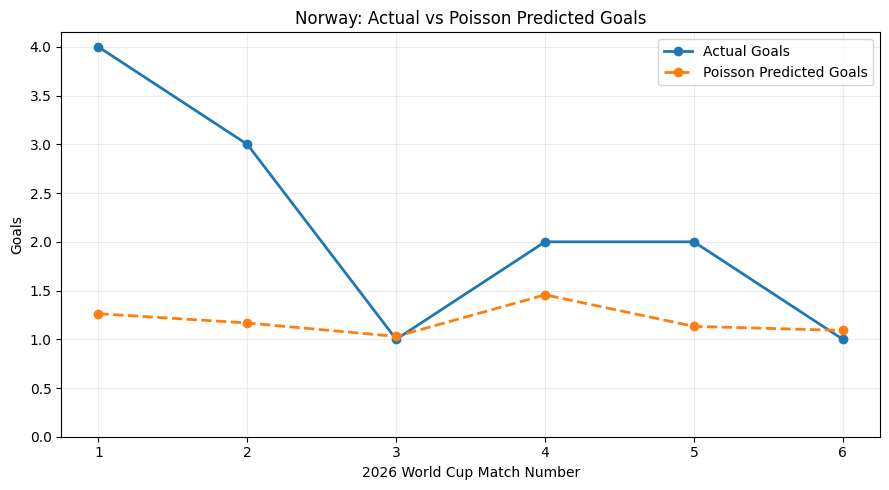

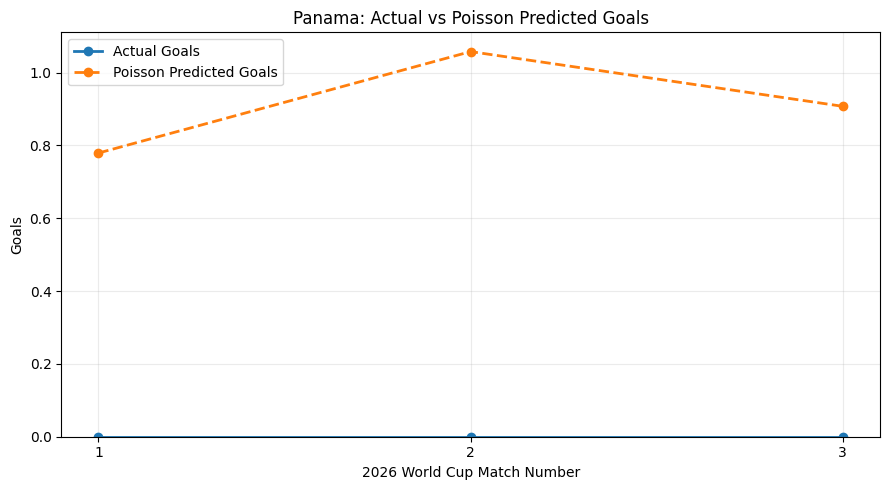

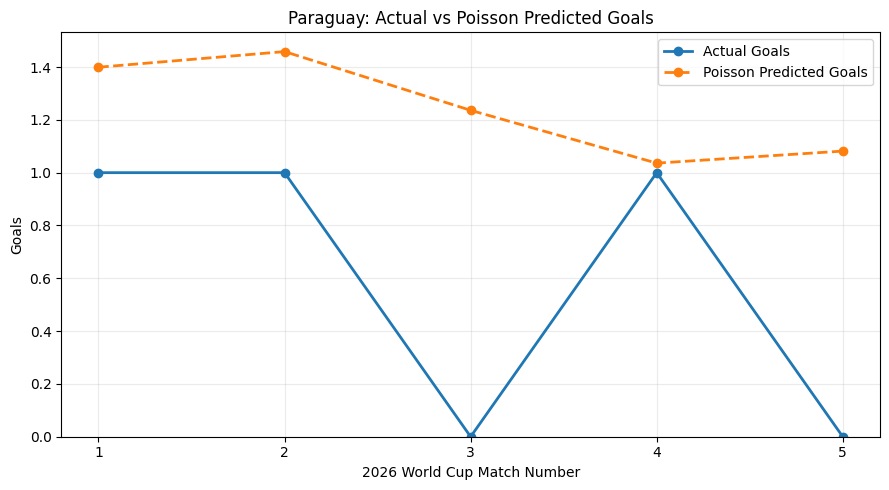

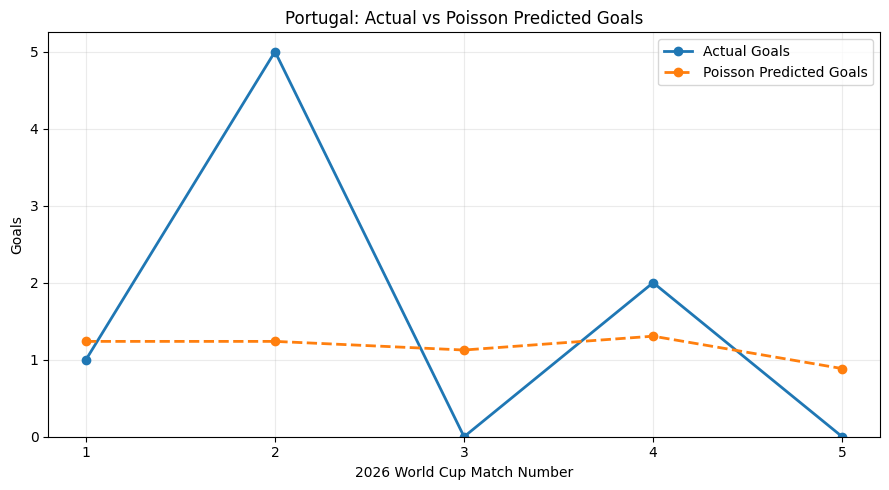

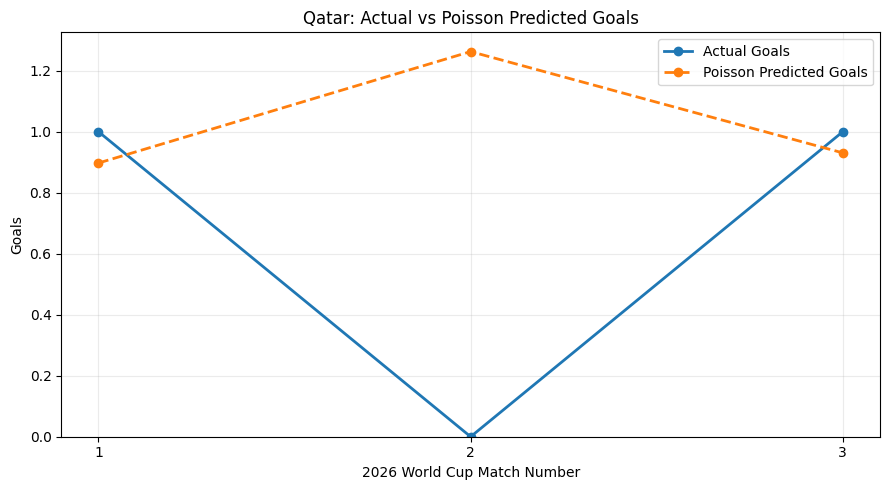

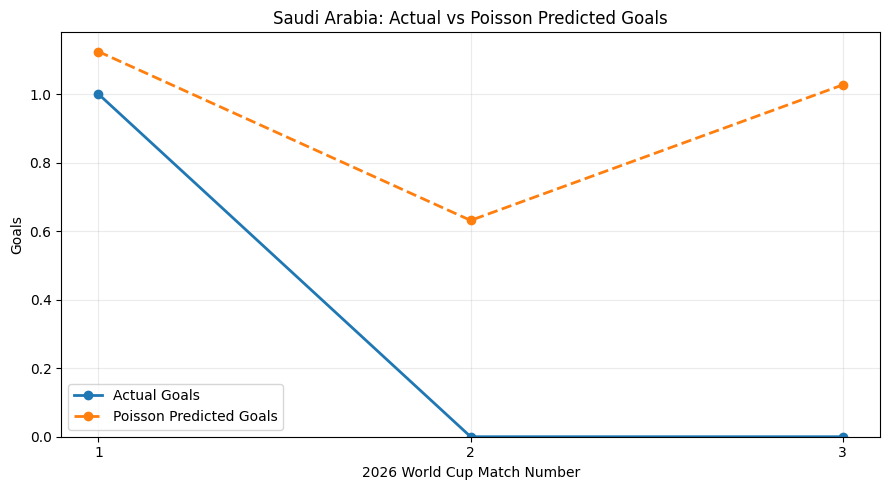

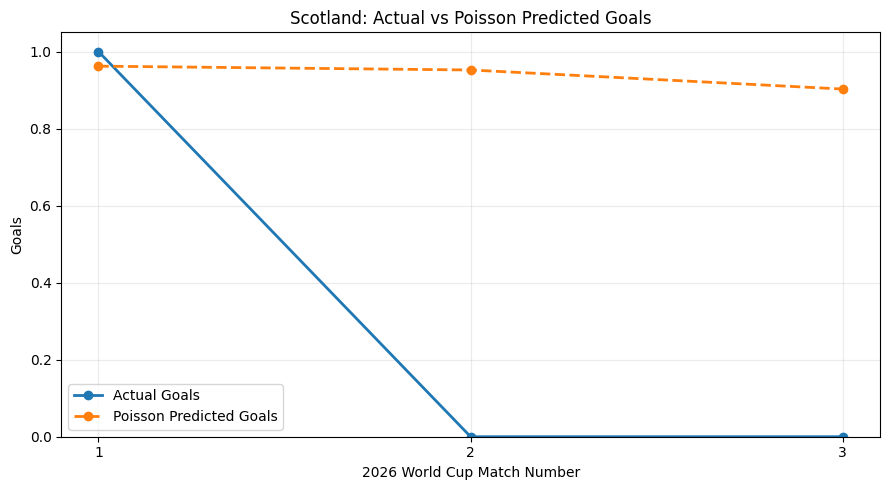

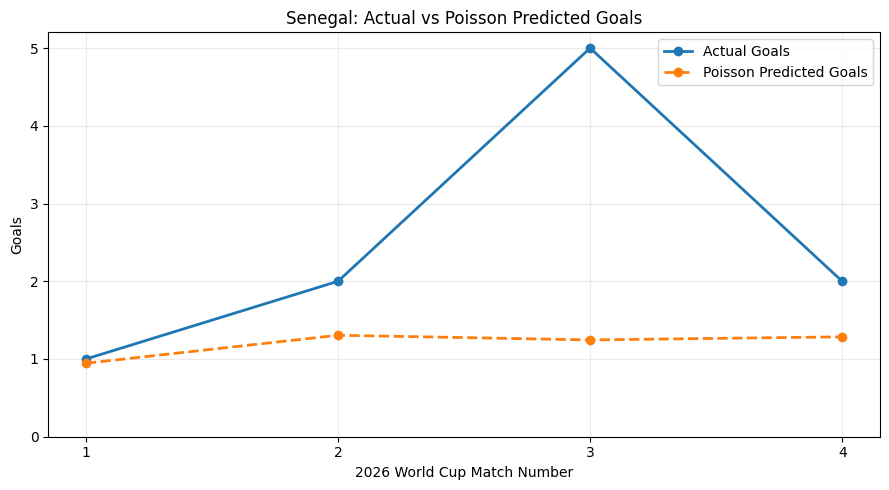

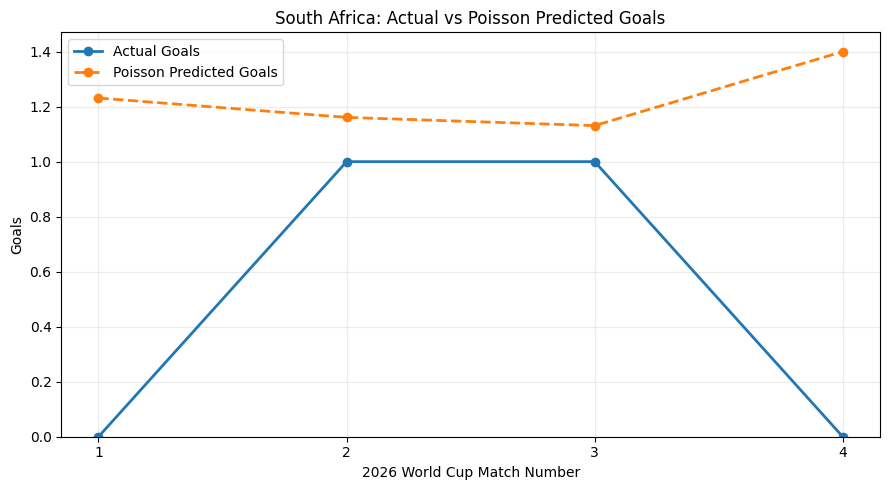

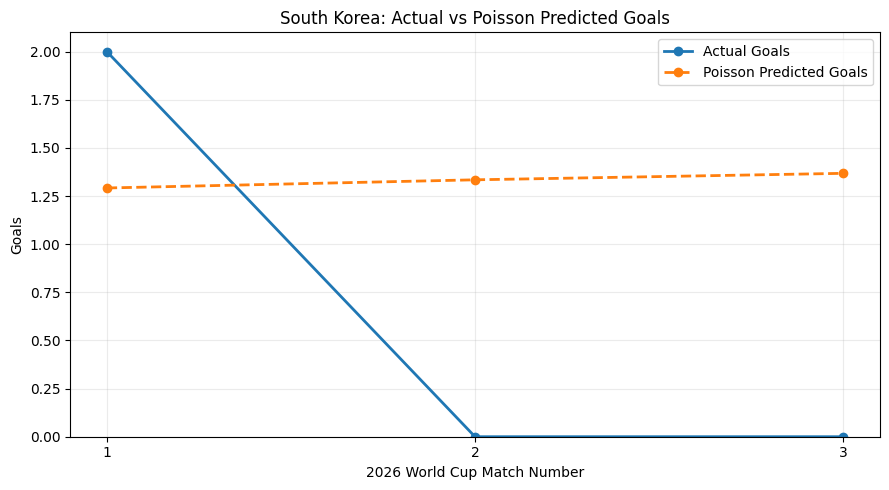

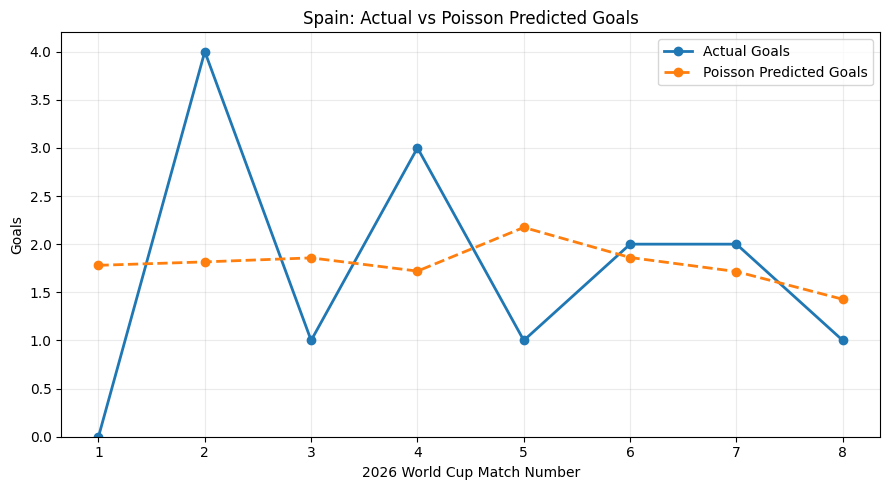

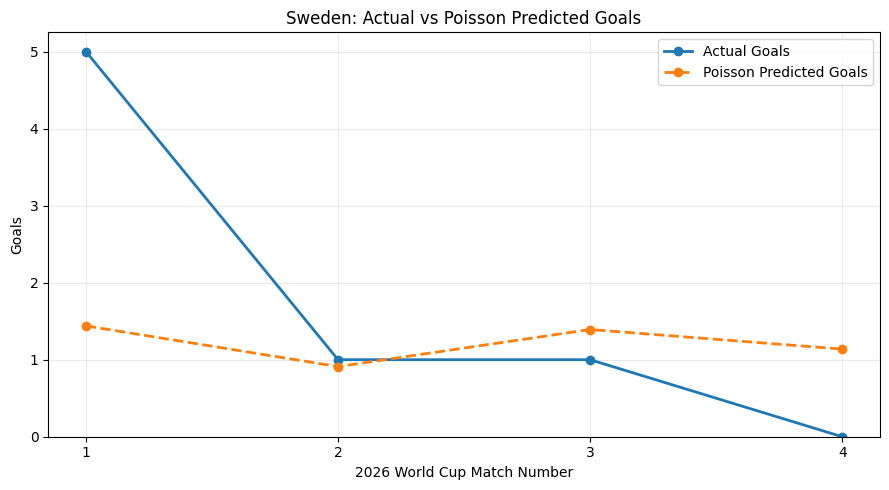

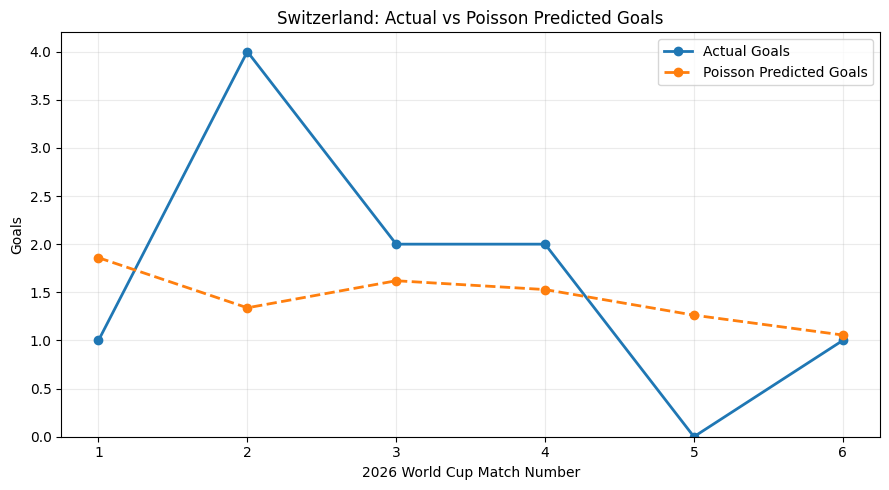

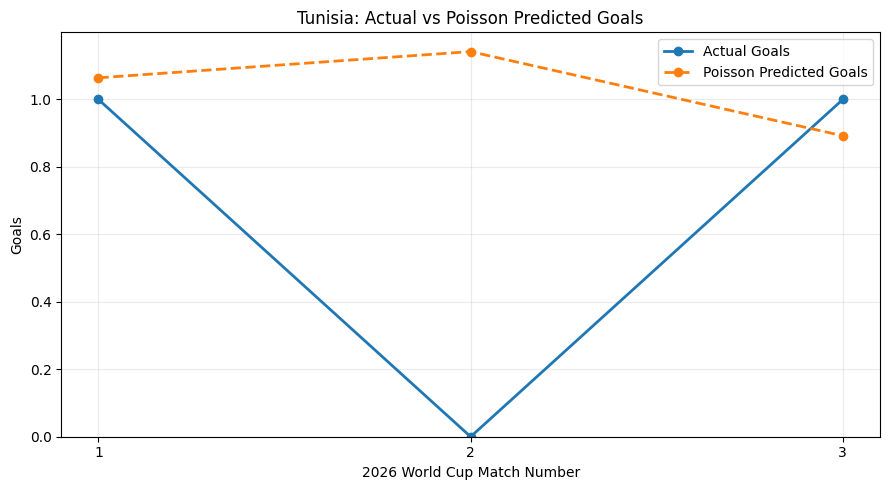

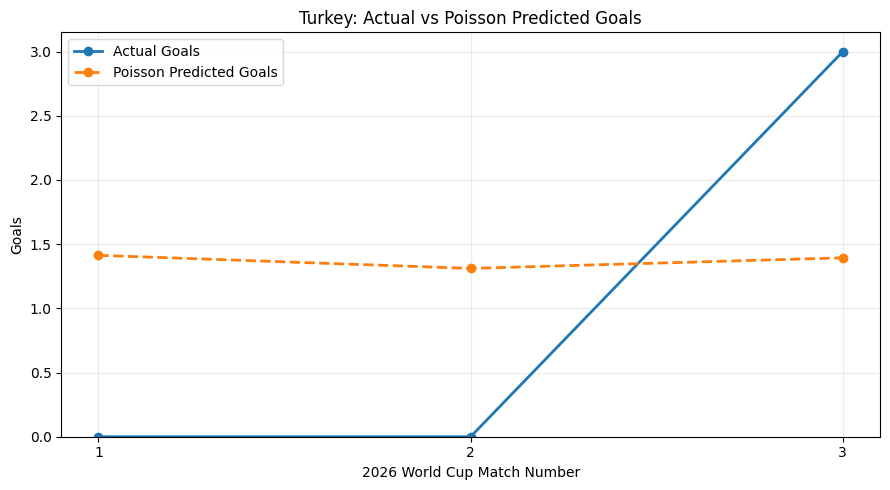

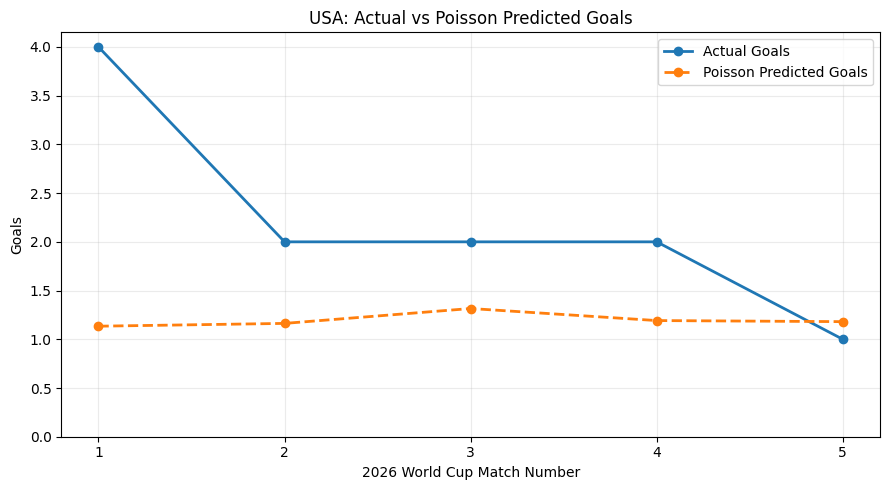

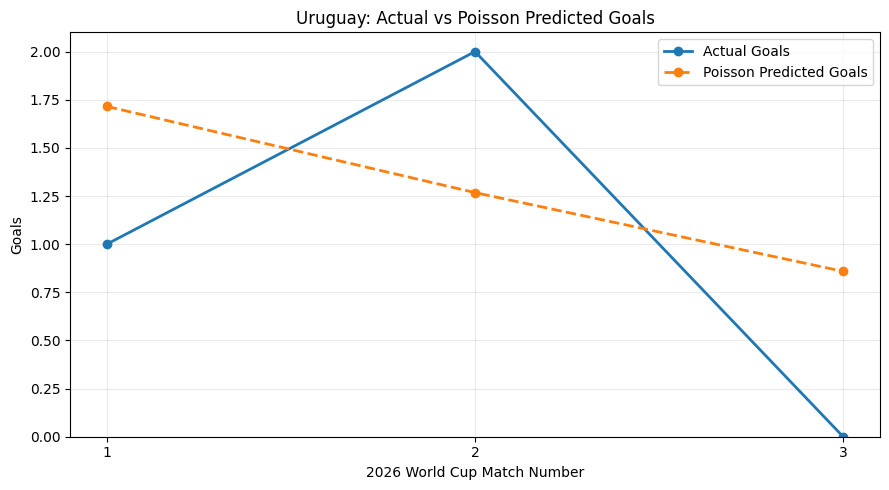

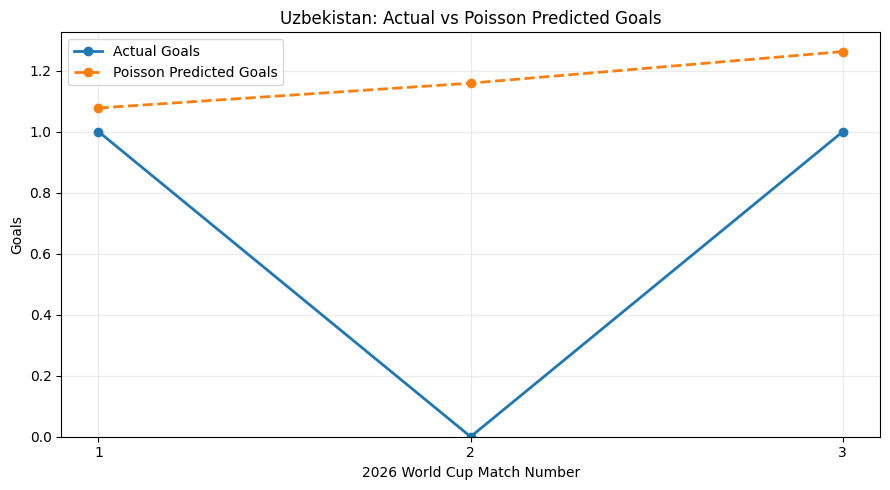

In [ ]:
import matplotlib.pyplot as plt

countries = sorted(
    country_poisson["country"].unique()
)

for country in countries:

    team_data = (
        country_poisson[
            country_poisson["country"] == country
        ]
        .copy()
    )

    plt.figure(figsize=(9, 5))

    # Actual goals
    plt.plot(
        team_data["match_number"],
        team_data["actual_goals"],
        marker="o",
        linewidth=2,
        label="Actual Goals"
    )

    # Poisson prediction
    plt.plot(
        team_data["match_number"],
        team_data["predicted_goals"],
        marker="o",
        linestyle="--",
        linewidth=2,
        label="Poisson Predicted Goals"
    )

    plt.title(
        f"{country}: Actual vs Poisson Predicted Goals"
    )

    plt.xlabel("2026 World Cup Match Number")
    plt.ylabel("Goals")

    plt.xticks(
        team_data["match_number"]
    )

    plt.ylim(
        bottom=0
    )

    plt.legend()
    plt.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

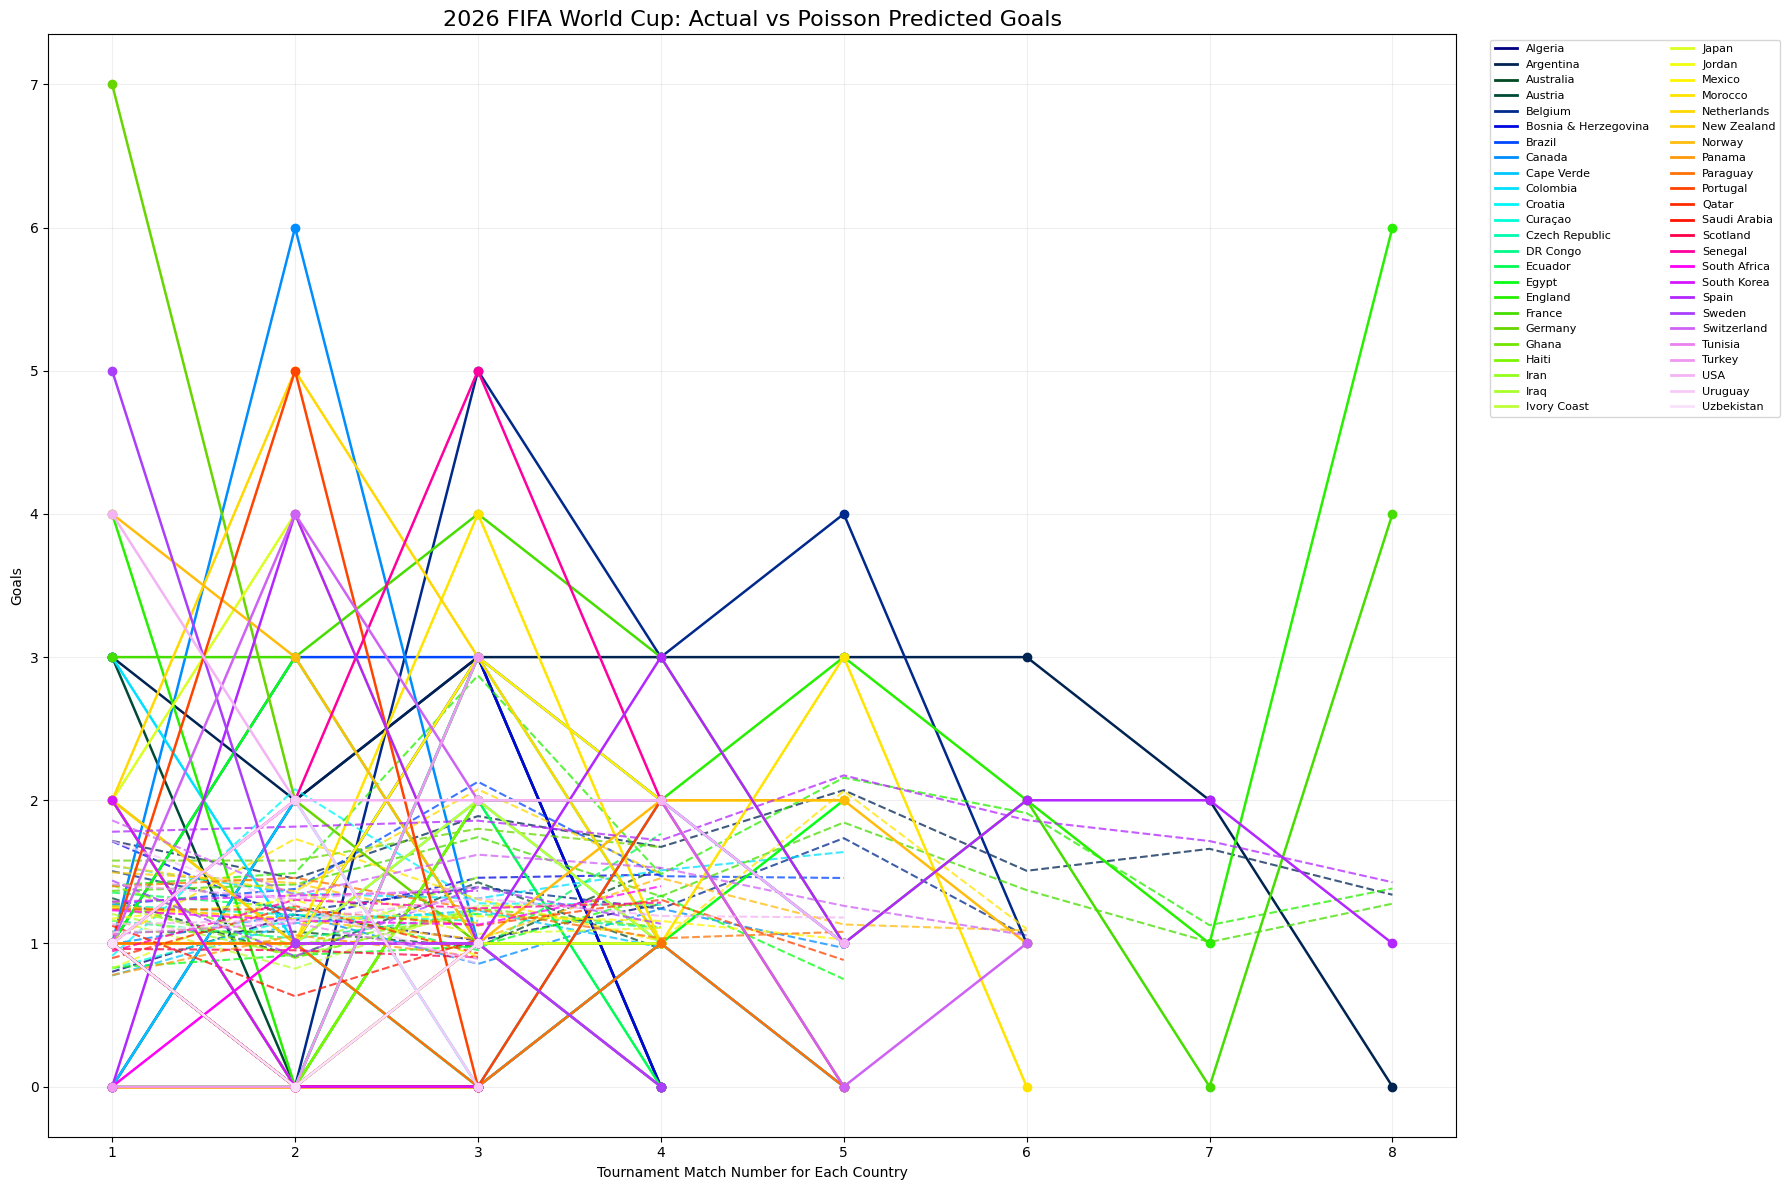

In [ ]:
import matplotlib.pyplot as plt

countries = sorted(
    country_poisson["country"].unique()
)

cmap = plt.colormaps["gist_ncar"]

colors = {
    country: cmap(i / len(countries))
    for i, country in enumerate(countries)
}

plt.figure(figsize=(18, 12))

for country in countries:

    team_data = (
        country_poisson[
            country_poisson["country"] == country
        ]
        .copy()
    )

    # ACTUAL
    plt.plot(
        team_data["match_number"],
        team_data["actual_goals"],
        marker="o",
        linewidth=1.8,
        color=colors[country],
        label=f"{country} — Actual"
    )

    # POISSON
    plt.plot(
        team_data["match_number"],
        team_data["predicted_goals"],
        linestyle="--",
        linewidth=1.5,
        color=colors[country],
        alpha=0.75
    )


plt.title(
    "2026 FIFA World Cup: Actual vs Poisson Predicted Goals",
    fontsize=16
)

plt.xlabel(
    "Tournament Match Number for Each Country"
)

plt.ylabel(
    "Goals"
)

plt.grid(
    alpha=0.20
)

# country legend only
handles = []

for country in countries:

    handle = plt.Line2D(
        [0],
        [0],
        color=colors[country],
        linewidth=2,
        label=country
    )

    handles.append(handle)


plt.legend(
    handles=handles,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8,
    ncol=2
)

plt.tight_layout()
plt.show()

In [ ]:
country_totals = (
    country_poisson
    .groupby("country", as_index=False)
    .agg(
        Actual_Goals=("actual_goals", "sum"),
        Poisson_Predicted_Goals=("predicted_goals", "sum"),
        Matches=("match_number", "count")
    )
)

country_totals = (
    country_totals
    .sort_values(
        "Actual_Goals",
        ascending=False
    )
    .reset_index(drop=True)
)

display(country_totals)

,country,Actual_Goals,Poisson_Predicted_Goals,Matches
0,France,20,11.355822,8
1,England,20,13.832979,8
2,Argentina,19,13.311783,8
3,Belgium,14,8.149916,6
4,Spain,14,14.351447,8
5,Norway,13,7.138581,6
6,Germany,11,6.631285,4
7,Netherlands,11,6.470619,4
8,USA,11,5.986086,5
9,Morocco,10,8.248752,6


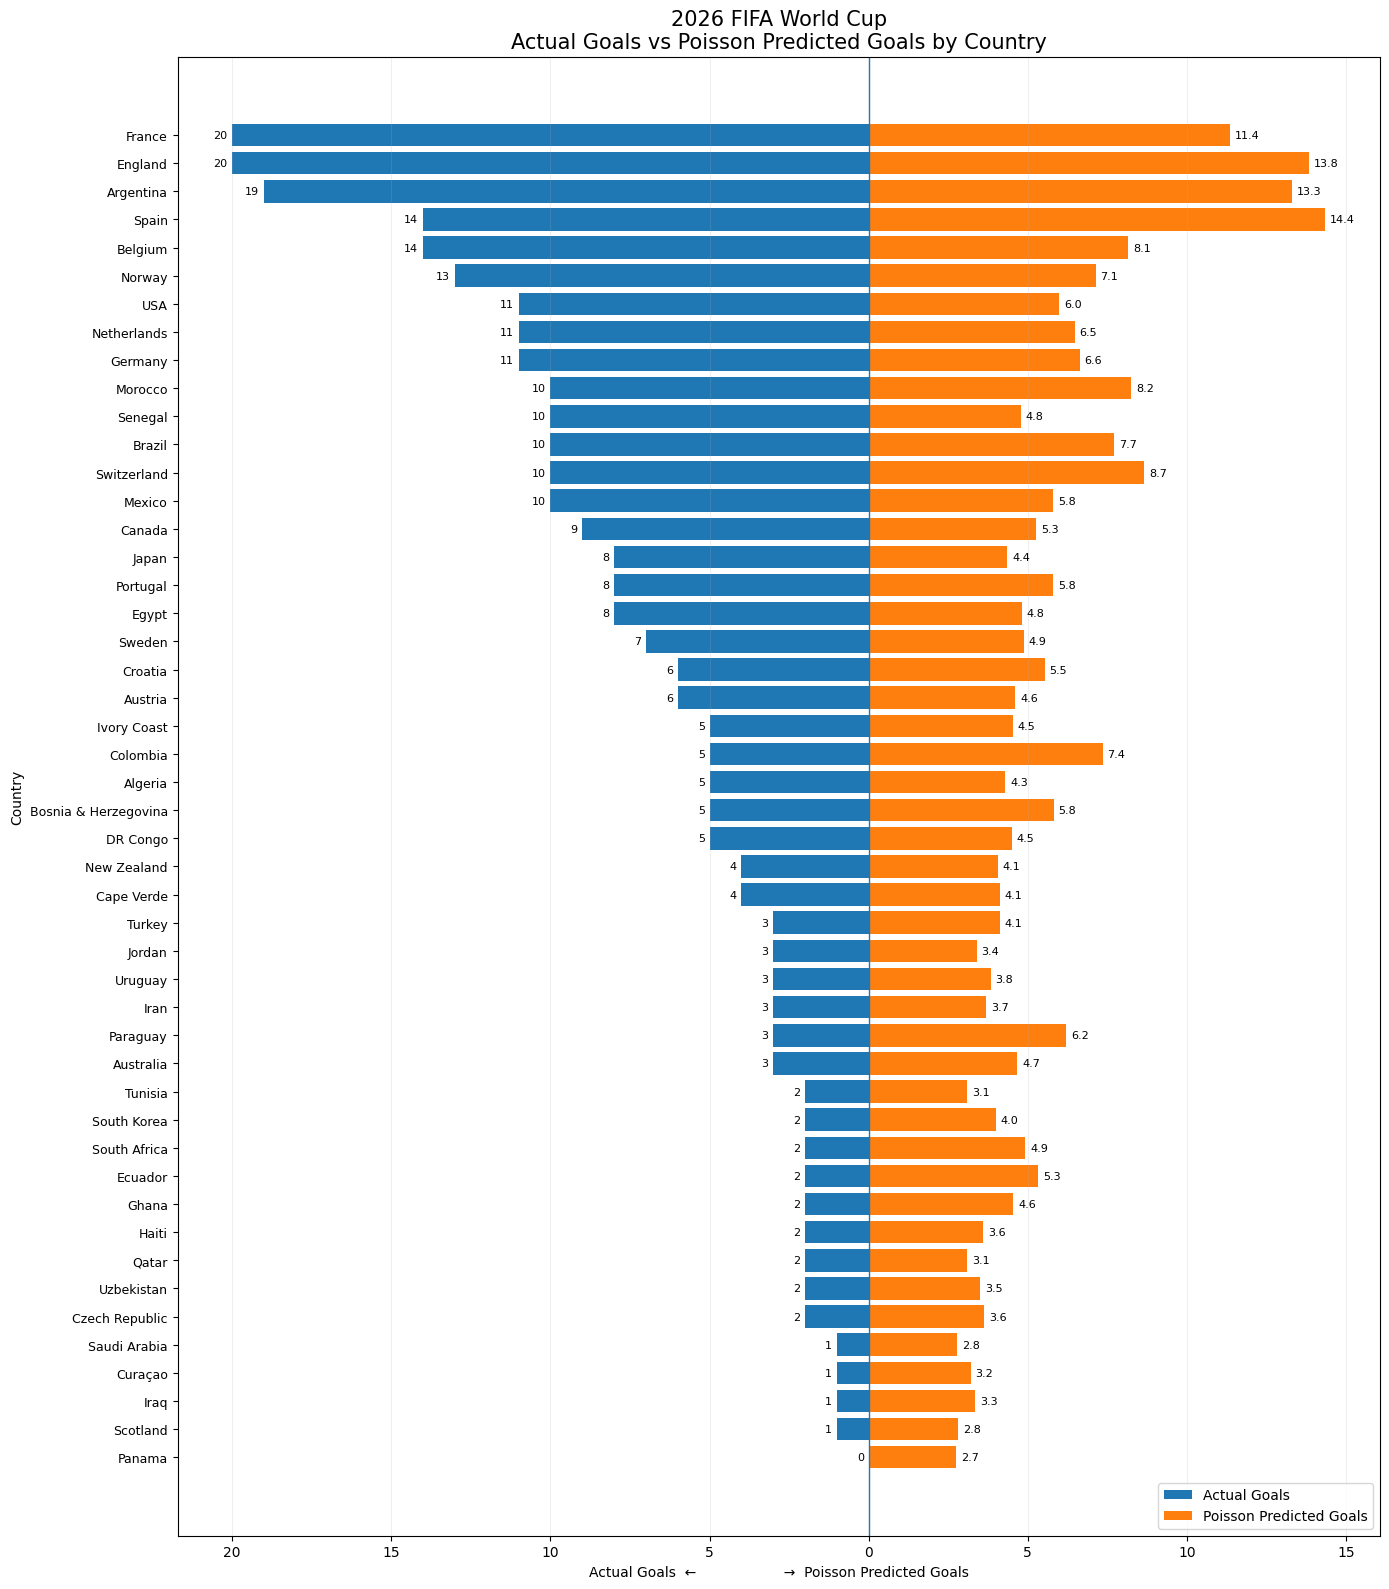

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plot_data = (
    country_totals
    .sort_values("Actual_Goals", ascending=True)
    .reset_index(drop=True)
)

countries = plot_data["country"]

actual = plot_data["Actual_Goals"]

predicted = plot_data["Poisson_Predicted_Goals"]

y = np.arange(len(countries))



fig, ax = plt.subplots(
    figsize=(14, 16)
)


# ACTUAL GOALS — extend LEFT
ax.barh(
    y,
    -actual,
    label="Actual Goals"
)


# POISSON PREDICTIONS — extend RIGHT
ax.barh(
    y,
    predicted,
    label="Poisson Predicted Goals"
)
ax.set_yticks(y)

ax.set_yticklabels(
    countries,
    fontsize=9
)


# Center line
ax.axvline(
    0,
    linewidth=1
)



for i, value in enumerate(actual):

    ax.text(
        -value - 0.15,
        i,
        f"{value:.0f}",
        va="center",
        ha="right",
        fontsize=8
    )


for i, value in enumerate(predicted):

    ax.text(
        value + 0.15,
        i,
        f"{value:.1f}",
        va="center",
        ha="left",
        fontsize=8
    )



ax.set_title(
    "2026 FIFA World Cup\n"
    "Actual Goals vs Poisson Predicted Goals by Country",
    fontsize=15
)

ax.set_xlabel(
    "Actual Goals  ←                    →  Poisson Predicted Goals"
)

ax.set_ylabel(
    "Country"
)

ax.legend(
    loc="lower right"
)

ax.grid(
    axis="x",
    alpha=0.20
)


ticks = ax.get_xticks()

ax.set_xticklabels(
    [
        str(abs(int(tick)))
        for tick in ticks
    ]
)


plt.tight_layout()

plt.show()

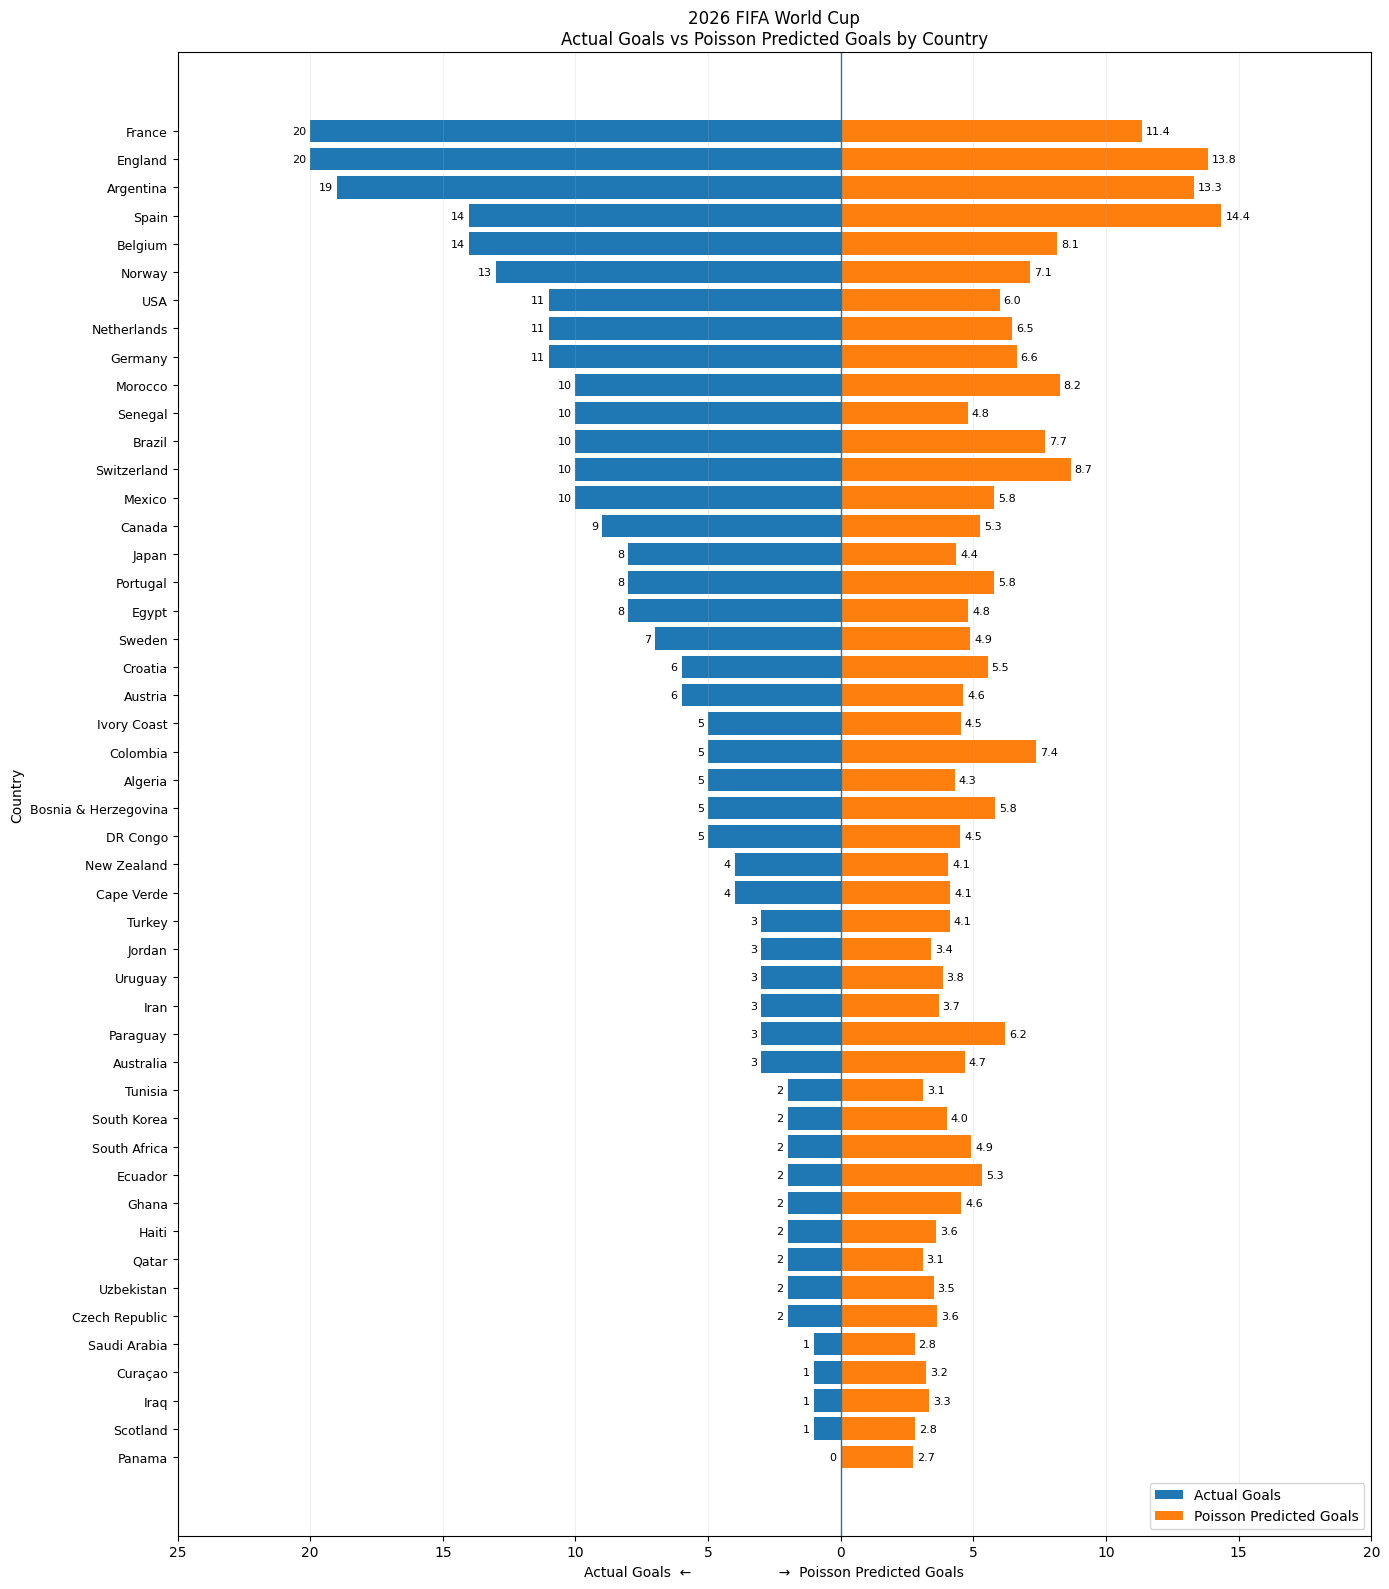

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
import matplotlib.pyplot as plt
import numpy as np

# sort countries by actual goals
plot_data = (
    country_totals
    .sort_values("Actual_Goals", ascending=True)
    .reset_index(drop=True)
)

countries = plot_data["country"]
actual = plot_data["Actual_Goals"]
predicted = plot_data["Poisson_Predicted_Goals"]

y = np.arange(len(countries))

# create figure
fig, ax = plt.subplots(figsize=(14, 16))

# actual goals on left
ax.barh(
    y,
    -actual,
    label="Actual Goals"
)

# predicted goals on right
ax.barh(
    y,
    predicted,
    label="Poisson Predicted Goals"
)

ax.set_yticks(y)
ax.set_yticklabels(countries, fontsize=9)

ax.axvline(0, linewidth=1)

for i, value in enumerate(actual):
    ax.text(
        -value - 0.15,
        i,
        f"{value:.0f}",
        va="center",
        ha="right",
        fontsize=8
    )

for i, value in enumerate(predicted):
    ax.text(
        value + 0.15,
        i,
        f"{value:.1f}",
        va="center",
        ha="left",
        fontsize=8
    )

ax.set_title(
    "2026 FIFA World Cup\n"
    "Actual Goals vs Poisson Predicted Goals by Country"
)

ax.set_xlabel(
    "Actual Goals  ←                    →  Poisson Predicted Goals"
)

ax.set_ylabel("Country")
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.20)

# make tick labels positive
ticks = ax.get_xticks()

ax.set_xticks(ticks)
ax.set_xticklabels(
    [str(abs(int(tick))) for tick in ticks]
)

plt.tight_layout()

# SAVE BEFORE SHOW
fig.savefig(
    "2026_actual_vs_poisson.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Download
files.download(
    "2026_actual_vs_poisson.png"
)

In [ ]:
from google.colab import files
import matplotlib.pyplot as plt

# Save the current graph
plt.savefig(
    '2026_actual_vs_poisson.png',
    bbox_inches='tight',
    dpi=300
)

# Download to your computer
files.download('2026_actual_vs_poisson.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 640x480 with 0 Axes>

In [ ]:
from google.colab import files
import matplotlib.pyplot as plt

# Save your plot first
plt.savefig('my_plot.png', bbox_inches='tight')

# Download the file to your computer
files.download('my_plot.png')

In [ ]:
plt.tight_layout()

# Save PNG
plt.savefig(
    "/content/2026_poisson_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

# Save PDF
plt.savefig(
    "/content/2026_poisson_actual_vs_predicted.pdf",
    bbox_inches="tight"
)

plt.show()

# Download
from google.colab import files

files.download(
    "/content/2026_poisson_actual_vs_predicted.png"
)

files.download(
    "/content/2026_poisson_actual_vs_predicted.pdf"
)

<Figure size 640x480 with 0 Axes>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

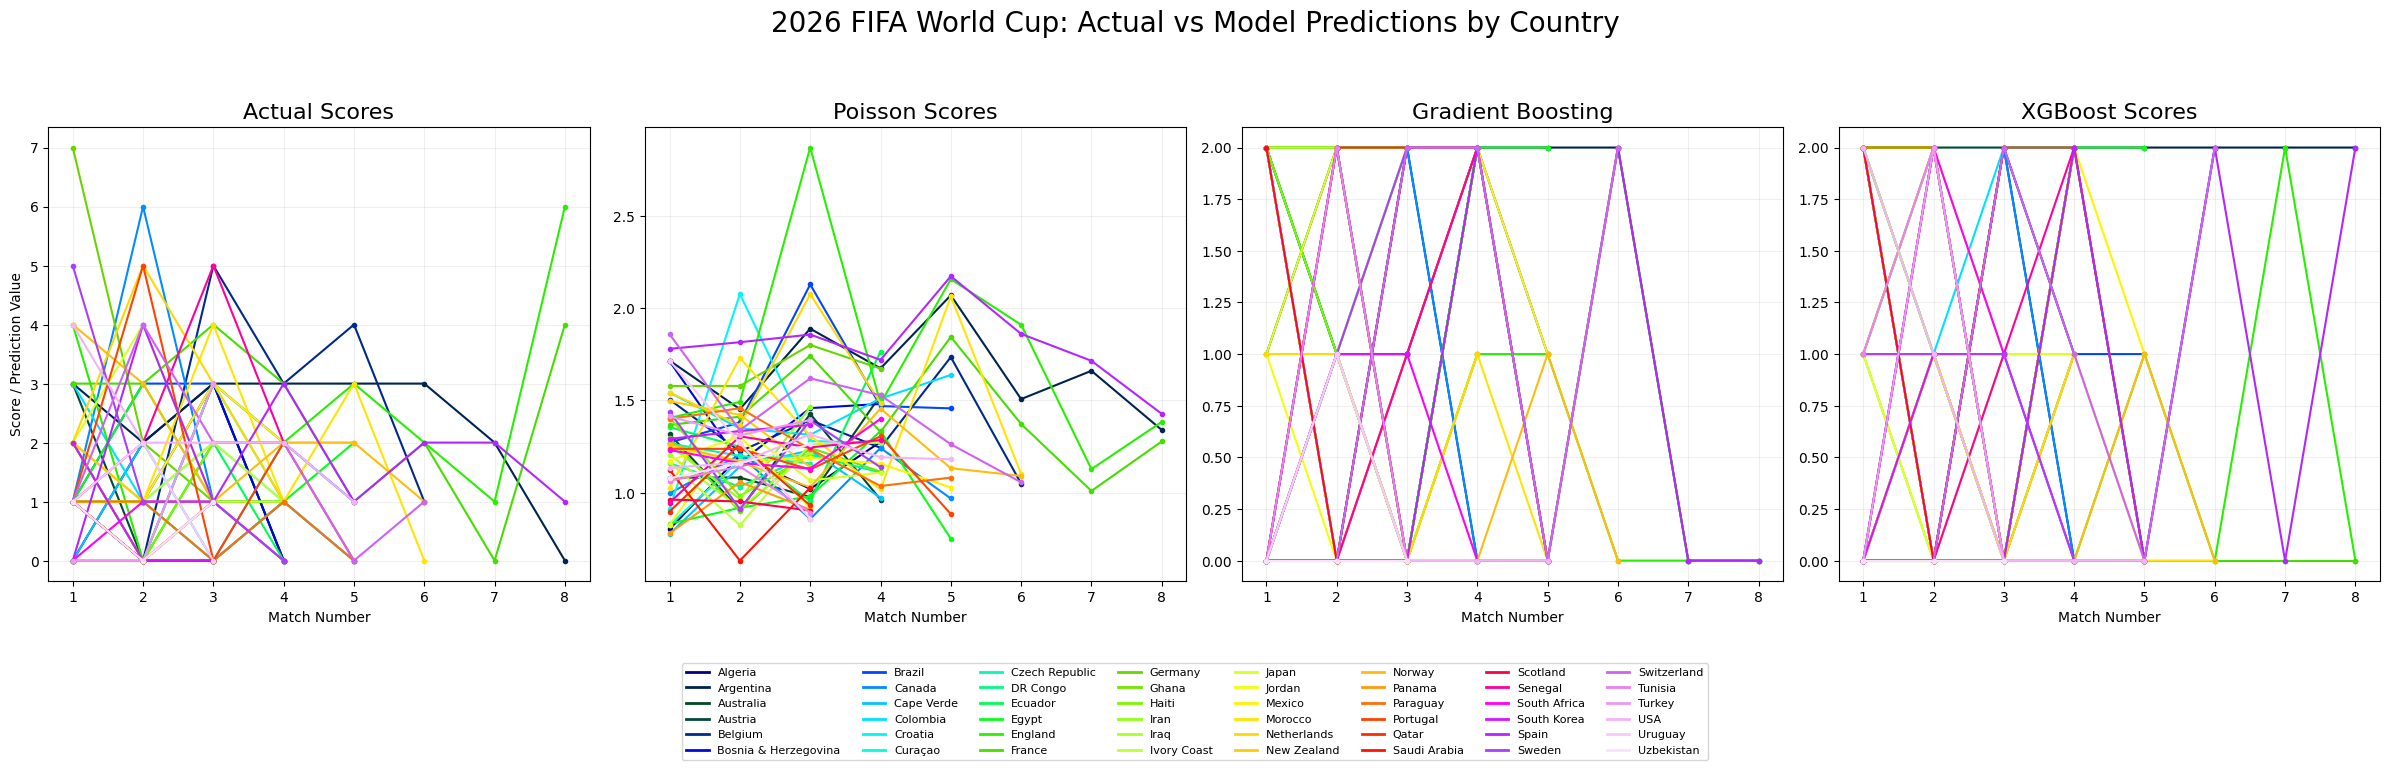

In [ ]:


import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


rows = []

for _, row in all_2026.iterrows():

    # Team A
    rows.append({
        "country": row["team_a"],
        "actual_goals": row["score_a"],
        "poisson_goals": row["Poisson_xG_A"],
        "logistic": row["Logistic"],
        "random_forest": row["Random_Forest"],
        "gradient_boosting": row["Gradient_Boosting"],
        "xgboost": row["XGBoost"]
    })

    # Team B
    rows.append({
        "country": row["team_b"],
        "actual_goals": row["score_b"],
        "poisson_goals": row["Poisson_xG_B"],
        "logistic": row["Logistic"],
        "random_forest": row["Random_Forest"],
        "gradient_boosting": row["Gradient_Boosting"],
        "xgboost": row["XGBoost"]
    })


country_lines = pd.DataFrame(rows)

# Number matches within each country
country_lines["match_number"] = (
    country_lines
    .groupby("country")
    .cumcount() + 1
)


countries = sorted(
    country_lines["country"].unique()
)

cmap = plt.colormaps["gist_ncar"]

country_colors = {
    country: cmap(i / len(countries))
    for i, country in enumerate(countries)
}



fig, axes = plt.subplots(
    1,
    4,
    figsize=(24, 7),
    sharex=False
)

metrics = [
    ("actual_goals", "Actual Scores"),
    ("poisson_goals", "Poisson Scores"),
    ("gradient_boosting", "Gradient Boosting"),
    ("xgboost", "XGBoost Scores")
]


for ax, (metric, title) in zip(
    axes,
    metrics
):

    for country in countries:

        team_data = (
            country_lines[
                country_lines["country"] == country
            ]
            .copy()
        )

        ax.plot(
            team_data["match_number"],
            team_data[metric],
            marker="o",
            linewidth=1.5,
            markersize=3,
            color=country_colors[country],
            label=country
        )

    ax.set_title(
        title,
        fontsize=16
    )

    ax.set_xlabel(
        "Match Number"
    )

    ax.grid(
        alpha=0.20
    )


axes[0].set_ylabel(
    "Score / Prediction Value"
)



handles = []

for country in countries:

    handle = plt.Line2D(
        [0],
        [0],
        color=country_colors[country],
        linewidth=2,
        label=country
    )

    handles.append(handle)


fig.legend(
    handles=handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.10),
    ncol=8,
    fontsize=8
)


fig.suptitle(
    "2026 FIFA World Cup: Actual vs Model Predictions by Country",
    fontsize=20
)

plt.tight_layout(
    rect=[0, 0.08, 1, 0.93]
)

plt.show()